In [153]:
import pandas as pd

In [154]:
files = [
    "C:/Users/praharshaanugu/MLprojects/social-media-trend-analyser/data/raw/2025-05-01.parquet",
    #"C:/Users/praharshaanugu/MLprojects/social-media-trend-analyser/data/raw/2025-05-02.parquet",
    #"C:/Users/praharshaanugu/MLprojects/social-media-trend-analyser/data/raw/2025-05-03.parquet"
]

df = pd.concat([
    pd.read_parquet(file)
    for file in files
])

In [155]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1041 entries, 0 to 1040
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                     
---  ------        --------------  -----                     
 0   subreddit     1041 non-null   str                       
 1   created_at    1041 non-null   datetime64[ns, US/Central]
 2   retrieved_at  1041 non-null   datetime64[ns, US/Central]
 3   type          1041 non-null   str                       
 4   text          1041 non-null   str                       
 5   score         1041 non-null   int64                     
 6   post_id       1041 non-null   str                       
 7   parent_id     844 non-null    str                       
dtypes: datetime64[ns, US/Central](2), int64(1), str(5)
memory usage: 464.2 KB


In [156]:
df.columns

Index(['subreddit', 'created_at', 'retrieved_at', 'type', 'text', 'score',
       'post_id', 'parent_id'],
      dtype='str')

In [157]:
df.head()

,subreddit,created_at,retrieved_at,type,text,score,post_id,parent_id
0,artificial,2025-05-01 10:46:37-05:00,2025-05-01 18:22:20.660913-05:00,post,"Incredible. After being pressed for a source for a claim, o3 claims it personally overheard someone say it at a conference in 2018:\n\n",147,1kcbzf3,NaN
1,artificial,2025-05-01 10:55:08-05:00,2025-05-01 18:22:20.660913-05:00,comment,So has it read this on a forum or something and repeating or just flat out hallucination,34,mq1d76o,t3_1kcbzf3
2,artificial,2025-05-01 11:33:51-05:00,2025-05-01 18:22:20.660913-05:00,comment,Hallucinations are the one speed-brake that is keeping AI from taking over entire industries. In a way we're all kinda lucky because it gives us time to adjust.\n\nImagine if these things came out of the gate with a 1% hallucination rate?,16,mq1kzk8,t3_1kcbzf3
3,artificial,2025-05-01 13:01:07-05:00,2025-05-01 18:22:20.660913-05:00,comment,LLMs don’t know the world exists outside of words about it.,11,mq23924,t3_1kcbzf3
4,artificial,2025-05-01 14:13:54-05:00,2025-05-01 18:22:20.660913-05:00,comment,"Stop using LLMs as fact machines, they are not that. Use them to produce deliverable elements of work that generate revenue for you. ""lies"" suggests it has intent, it doesn't. Its just guessing the next most likely word someone else would say in response to what you asked.",10,mq2i16c,t3_1kcbzf3


In [158]:
df.isnull().sum()

subreddit         0
created_at        0
retrieved_at      0
type              0
text              0
score             0
post_id           0
parent_id       197
dtype: int64

In [159]:
df.describe(include="all")

,subreddit,created_at,retrieved_at,type,text,score,post_id,parent_id
count,1041,1041,1041,1041,1041,1041.000000,1041,844
unique,4,NaN,NaN,2,1036,NaN,1041,168
top,LocalLLaMA,NaN,NaN,comment,"Feels sci-fi to watch it ""zoom and enhance"" while geoguessing\n\n",NaN,1kcbzf3,t3_1kcbzf3
freq,523,NaN,NaN,844,3,NaN,1,10
mean,NaN,2025-05-01 08:27:04.967339008-05:00,2025-05-01 18:22:39.930800640-05:00,NaN,NaN,25.522574,NaN,NaN
min,NaN,2025-04-30 18:10:44-05:00,2025-05-01 18:22:20.660913-05:00,NaN,NaN,-41.000000,NaN,NaN
25%,NaN,2025-05-01 03:04:04-05:00,2025-05-01 18:22:26.071697920-05:00,NaN,NaN,1.000000,NaN,NaN
50%,NaN,2025-05-01 10:29:08-05:00,2025-05-01 18:22:26.071697920-05:00,NaN,NaN,3.000000,NaN,NaN
75%,NaN,2025-05-01 13:29:33-05:00,2025-05-01 18:22:53.001740032-05:00,NaN,NaN,12.000000,NaN,NaN
max,NaN,2025-05-01 18:22:03-05:00,2025-05-01 18:23:06.503195-05:00,NaN,NaN,2304.000000,NaN,NaN


In [160]:
df.shape

(1041, 8)

EDA

Post vs comment

In [161]:
df["type"].value_counts()

type
comment    844
post       197
Name: count, dtype: int64

No of subreddits

In [162]:
df["subreddit"].nunique()

4

In [163]:
df["subreddit"].value_counts().head(20)

subreddit
LocalLLaMA     523
OpenAI         227
singularity    211
artificial      80
Name: count, dtype: int64

Data/Time Range

In [164]:
print("Start:", df["created_at"].min())
print("End:", df["created_at"].max())

Start: 2025-04-30 18:10:44-05:00
End: 2025-05-01 18:22:03-05:00


Score Statistics

In [165]:
df["score"].describe()

count    1041.000000
mean       25.522574
std       112.633108
min       -41.000000
25%         1.000000
50%         3.000000
75%        12.000000
max      2304.000000
Name: score, dtype: float64

Duplicate Records

In [166]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate post IDs:", df["post_id"].duplicated().sum())

Duplicate rows: 0
Duplicate post IDs: 0


Text Lenght

In [167]:
df["text_length"] = df["text"].str.len()

df["text_length"].describe()

count    1041.000000
mean      359.771374
std       662.831590
min         2.000000
25%        63.000000
50%       152.000000
75%       378.000000
max      9758.000000
Name: text_length, dtype: float64

Visualization

<Axes: title={'center': 'Posts vs Comments'}, xlabel='type'>

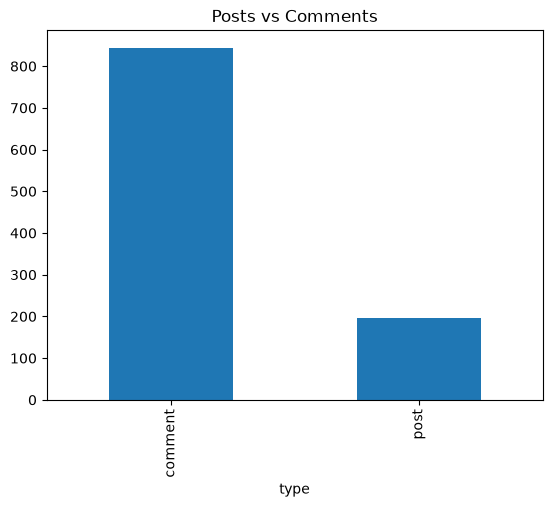

In [168]:
df["type"].value_counts().plot(kind="bar", title="Posts vs Comments")

<Axes: title={'center': 'Distribution of Reddit Scores'}, ylabel='Frequency'>

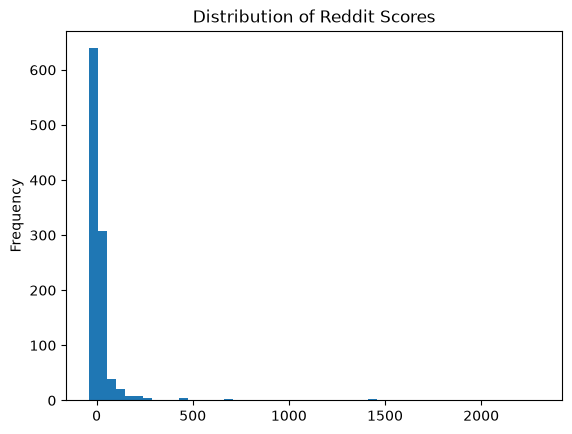

In [169]:
df["score"].plot(kind="hist", bins=50, title="Distribution of Reddit Scores")

Concating all 3 files

In [170]:
files = [
    "C:/Users/praharshaanugu/MLprojects/social-media-trend-analyser/data/raw/2025-05-01.parquet",
    "C:/Users/praharshaanugu/MLprojects/social-media-trend-analyser/data/raw/2025-05-02.parquet",
    "C:/Users/praharshaanugu/MLprojects/social-media-trend-analyser/data/raw/2025-05-03.parquet"
]

dfs = [pd.read_parquet(file) for file in files]
df_all = pd.concat(dfs, ignore_index=True)

print(df_all.shape)

(2902, 8)


In [171]:
df_all["created_at"].min(), df_all["created_at"].max()

(Timestamp('2025-04-30 18:10:44-0500', tz='US/Central'),
 Timestamp('2025-05-03 18:21:10-0500', tz='US/Central'))

In [172]:
df_all["type"].value_counts()

type
comment    2393
post        509
Name: count, dtype: int64

In [173]:
df_all.groupby(
    df_all["created_at"].dt.date
).size()

created_at
2025-04-30     163
2025-05-01    1014
2025-05-02     876
2025-05-03     849
dtype: int64

Daily Actitviy

In [174]:
daily_counts = (
    df_all
    .groupby(df_all["created_at"].dt.date)
    .size()
)

daily_counts

created_at
2025-04-30     163
2025-05-01    1014
2025-05-02     876
2025-05-03     849
dtype: int64

Posts vs comments per day

In [175]:
daily_type = pd.crosstab(
    df_all["created_at"].dt.date,
    df_all["type"]
)

daily_type

type,comment,post
created_at,,
2025-04-30,121,42
2025-05-01,824,190
2025-05-02,724,152
2025-05-03,724,125


Subreddit activity per day

In [176]:
daily_subreddit = pd.crosstab(
    df_all["created_at"].dt.date,
    df_all["subreddit"]
)

daily_subreddit

subreddit,LocalLLaMA,OpenAI,artificial,singularity
created_at,,,,
2025-04-30,96,26,17,24
2025-05-01,471,265,66,212
2025-05-02,378,238,46,214
2025-05-03,359,239,53,198


14 files

In [177]:
from pathlib import Path

files = sorted(Path("../data/raw").glob("*.parquet"))

print("Number of files:", len(files))

for file in files:
    print(file.name)

Number of files: 14
2025-05-01.parquet
2025-05-02.parquet
2025-05-03.parquet
2025-05-04.parquet
2025-05-05.parquet
2025-05-06.parquet
2025-05-07.parquet
2025-05-08.parquet
2025-05-09.parquet
2025-05-10.parquet
2025-05-11.parquet
2025-05-12.parquet
2025-05-13.parquet
2025-05-14.parquet


In [178]:
dfs = [pd.read_parquet(file) for file in files]

df_all = pd.concat(dfs, ignore_index=True)

print("Shape:", df_all.shape)

Shape: (12626, 8)


Checking Time range

In [179]:
print("Start:", df_all["created_at"].min())
print("End:", df_all["created_at"].max())

Start: 2025-04-30 18:10:44-05:00
End: 2025-05-14 18:22:00-05:00


checking activity by day

In [180]:
daily_counts = (
    df_all
    .groupby(df_all["created_at"].dt.date)
    .size()
)

daily_counts

created_at
2025-04-30     163
2025-05-01    1014
2025-05-02     876
2025-05-03     985
2025-05-04     789
2025-05-05     950
2025-05-06    1043
2025-05-07     822
2025-05-08     917
2025-05-09     935
2025-05-10     806
2025-05-11     741
2025-05-12     864
2025-05-13     859
2025-05-14     862
dtype: int64

Plots

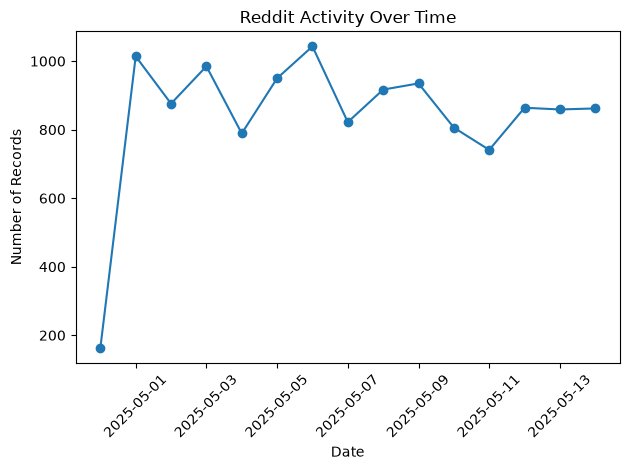

In [181]:
import matplotlib.pyplot as plt

daily_counts.plot(
    kind="line",
    marker="o",
    title="Reddit Activity Over Time",
    xlabel="Date",
    ylabel="Number of Records"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Lets seperate posts and comments

In [182]:
daily_type = pd.crosstab(
    df_all["created_at"].dt.date,
    df_all["type"]
)

daily_type

type,comment,post
created_at,,
2025-04-30,121,42
2025-05-01,824,190
2025-05-02,724,152
2025-05-03,823,162
2025-05-04,661,128
2025-05-05,790,160
2025-05-06,858,185
2025-05-07,680,142
2025-05-08,769,148


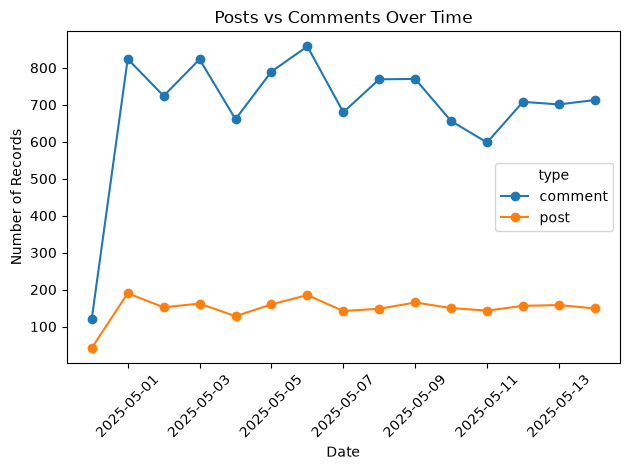

In [183]:
daily_type.plot(
    kind="line",
    marker="o",
    title="Posts vs Comments Over Time",
    xlabel="Date",
    ylabel="Number of Records"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [184]:
daily_subreddit = pd.crosstab(
    df_all["created_at"].dt.date,
    df_all["subreddit"]
)

daily_subreddit

subreddit,LocalLLaMA,OpenAI,artificial,singularity
created_at,,,,
2025-04-30,96,26,17,24
2025-05-01,471,265,66,212
2025-05-02,378,238,46,214
2025-05-03,429,292,57,207
2025-05-04,303,230,56,200
2025-05-05,466,247,36,201
2025-05-06,410,270,104,259
2025-05-07,324,217,96,185
2025-05-08,345,295,47,230


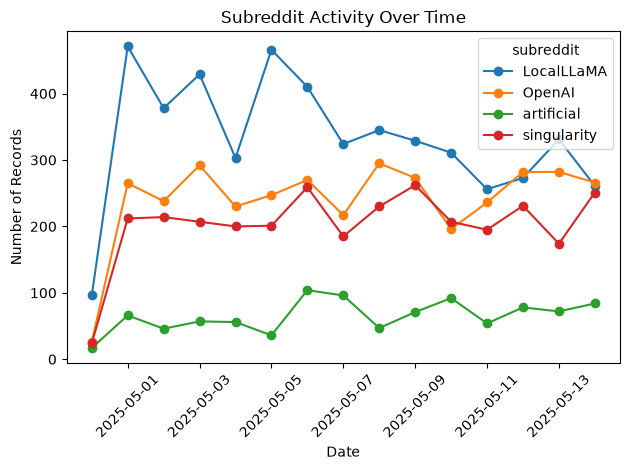

In [185]:
daily_subreddit.plot(
    kind="line",
    marker="o",
    title="Subreddit Activity Over Time",
    xlabel="Date",
    ylabel="Number of Records"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [186]:
pd.set_option("display.max_colwidth", 300)

df_all[[
    "created_at",
    "subreddit",
    "type",
    "text",
    "score"
]].head(20)

,created_at,subreddit,type,text,score
0,2025-05-01 10:46:37-05:00,artificial,post,"Incredible. After being pressed for a source for a claim, o3 claims it personally overheard someone say it at a conference in 2018:\n\n",147
1,2025-05-01 10:55:08-05:00,artificial,comment,So has it read this on a forum or something and repeating or just flat out hallucination,34
2,2025-05-01 11:33:51-05:00,artificial,comment,Hallucinations are the one speed-brake that is keeping AI from taking over entire industries. In a way we're all kinda lucky because it gives us time to adjust.\n\nImagine if these things came out of the gate with a 1% hallucination rate?,16
3,2025-05-01 13:01:07-05:00,artificial,comment,LLMs don’t know the world exists outside of words about it.,11
4,2025-05-01 14:13:54-05:00,artificial,comment,"Stop using LLMs as fact machines, they are not that. Use them to produce deliverable elements of work that generate revenue for you. ""lies"" suggests it has intent, it doesn't. Its just guessing the next most likely word someone else would say in response to what you asked.",10
5,2025-05-01 14:37:18-05:00,artificial,comment,https://preview.redd.it/0uz86wqq38ye1.jpeg?width=519&format=pjpg&auto=webp&s=24159d028e9eea51a7b08cee6baca7939439905a,2
6,2025-05-01 13:57:01-05:00,artificial,comment,4o has been doing this to me several times a day as well,1
7,2025-05-01 14:16:15-05:00,artificial,comment,🤣🤣🤣,1
8,2025-05-01 15:17:44-05:00,artificial,comment,"Yep.. some of the AI results from chrome search are just purely incorrect and even illogical at a base level. Easy to manipulate the LLM to say pretty much what you want. It’s pretty simple garbage in garbage out, trained on redit posts :D",1
9,2025-05-01 15:20:23-05:00,artificial,comment,"The real news is that people have begun to trust LLMs so much that they're outraged when they hallucinate.\n\nIt says a lot about how far they've come, and how quickly our expectations adjusted. Nobody would have batted an eye at this a year ago.",1


In [187]:
df_all["text"].sample(20, random_state=42)

7058                                                                                                             Dude, I'm desperately holding on to my youth so that I can hold out for the good rejuvenation shit.\n\nI mean, I still look great, but I've got full blown hip arthritis and terrible haemorrhoids.
6876                                                                                                                                                                                                                                 Yes, barely. You'll have to load a lot of the model into RAM and it'll be slow.
4862                                                                                                              Nvidia Nemotron and IBM Granite models are always a hard pass for me.    The benchmarks are always mouth watering, but they just never come close.   I hope it's just me, what are we doing wrong?
5470                                                                     

Text Processing

Make a copy

In [188]:
df_text = df_all.copy()

Inspect Problamatic text

In [189]:
print("Total records:", len(df_text))

print("Empty texts:", df_text["text"].isna().sum())

print("Very short texts (<20 chars):",
      (df_text["text"].str.len() < 20).sum())

print("Very long texts (>5000 chars):",
      (df_text["text"].str.len() > 5000).sum())

Total records: 12626
Empty texts: 0
Very short texts (<20 chars): 728
Very long texts (>5000 chars): 54


Cleaning function

In [190]:
import re

def clean_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Remove Reddit/Markdown links
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)

    # Remove markdown formatting
    text = re.sub(r'[*_~`]', ' ', text)

    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [191]:
df_text["clean_text"] = df_text["text"].apply(clean_text)

In [192]:
df_text[["text", "clean_text"]].sample(
    15,
    random_state=42
)

,text,clean_text
7058,"Dude, I'm desperately holding on to my youth so that I can hold out for the good rejuvenation shit.\n\nI mean, I still look great, but I've got full blown hip arthritis and terrible haemorrhoids.","Dude, I'm desperately holding on to my youth so that I can hold out for the good rejuvenation shit. I mean, I still look great, but I've got full blown hip arthritis and terrible haemorrhoids."
6876,"Yes, barely. You'll have to load a lot of the model into RAM and it'll be slow.","Yes, barely. You'll have to load a lot of the model into RAM and it'll be slow."
4862,"Nvidia Nemotron and IBM Granite models are always a hard pass for me. The benchmarks are always mouth watering, but they just never come close. I hope it's just me, what are we doing wrong?","Nvidia Nemotron and IBM Granite models are always a hard pass for me. The benchmarks are always mouth watering, but they just never come close. I hope it's just me, what are we doing wrong?"
5470,Looks like it can still generate reddit posts,Looks like it can still generate reddit posts
7407,"Historical/Religious bias is wild\n\nI learned today that ChatGPT has an extreme response to being asked about history and religion for some reason. \n\nMy use case: I asked about Dionysus, and related rituals. It began to flat-out tell me that it was against it's guidelines to talk in detail ab...","Historical/Religious bias is wild I learned today that ChatGPT has an extreme response to being asked about history and religion for some reason. My use case: I asked about Dionysus, and related rituals. It began to flat-out tell me that it was against it's guidelines to talk in detail about the..."
6720,"a pentium 2 is vintage, not modest hardware.\n\n\ngo a little newer for PCIE and gg, you can cheat with llama.cpp and a modern GPU, no need for 230 thousand params models. \nkepler supports win2k, and maxwell supports winxp and maybe 2k. 2x M6000s (or 1 m6000 and 1 m40) and you've got the ultima...","a pentium 2 is vintage, not modest hardware. go a little newer for PCIE and gg, you can cheat with llama.cpp and a modern GPU, no need for 230 thousand params models. kepler supports win2k, and maxwell supports winxp and maybe 2k. 2x M6000s (or 1 m6000 and 1 m40) and you've got the ultimate vint..."
724,"r/BuyFromEU say no to blackmail, take a stance!","r/BuyFromEU say no to blackmail, take a stance!"
8769,Why was the last one blocked?,Why was the last one blocked?
2608,"Is there a path for AI to advance to more complex conversations beyond the singular input-output text?\n\nI wonder if we will have an AI that can:\n\nRecognize multiple faces and voices\n\nHear when multiple people are talking at once and admit confusion if it's present, rather than take a singu...","Is there a path for AI to advance to more complex conversations beyond the singular input-output text? I wonder if we will have an AI that can: Recognize multiple faces and voices Hear when multiple people are talking at once and admit confusion if it's present, rather than take a singular input..."
12470,In order to get it to think for longer (longer isn’t always better) you must prompt it in a way that it uses one of its tools,In order to get it to think for longer (longer isn’t always better) you must prompt it in a way that it uses one of its tools


In [193]:
df_posts = df_text[df_text["type"] == "post"].copy()

print("Total posts:", len(df_posts))

Total posts: 2230


In [194]:
df_posts = df_posts[
    df_posts["clean_text"].str.len() >= 30
].copy()

print("Posts after length filtering:", len(df_posts))

Posts after length filtering: 2158


In [195]:
df_posts[[
    "created_at",
    "subreddit",
    "text",
    "score"
]].sample(30, random_state=42)

,created_at,subreddit,text,score
6001,2025-05-07 14:15:23-05:00,LocalLLaMA,"Trying out the Ace-Step Song Generation Model\n\nSo, I got Gemini to whip up some lyrics for an alphabet song, and then I used ACE-Step-v1-3.5B to generate a rock-style track at 105bpm. \n \nGive it a listen – how does it sound to you?\n\nMy feeling is that some of the transitions are still a ...",18
2064,2025-05-03 06:00:49-05:00,LocalLLaMA,Teaching LLMs to use tools with RL! Successfully trained 0.5B/3B Qwen models to use a calculator tool 🔨\n\n**👋 I recently had great fun training small language models (Qwen2.5 0.5B & 3B) to use a slightly complex calculator syntax through multi-turn reinforcement learning. Results were pretty co...,82
2398,2025-05-03 10:36:51-05:00,LocalLLaMA,"The GPT-4o sycophancy saga seems to be a case against open-source decentralized models?\n\nCorrect me if I am wrong, but it seems to me that much of the damage in this case could be mitigated because GPT-4o was a closed-source centralized model? One rollback and boom, no one on earth has access ...",0
6642,2025-05-08 07:55:52-05:00,LocalLLaMA,"Smoothie Qwen: A lightweight adjustment tool for smoothing token probabilities in the Qwen models to encourage balanced multilingual generation.\n\n**Smoothie Qwen** is a lightweight adjustment tool that smooths token probabilities in Qwen models, enhancing balanced multilingual generation capab...",85
2866,2025-05-03 03:51:57-05:00,OpenAI,Cam someone help me?\n\nCam someone gimme a graph that shows the real life AI growth from 2020 to 2030 ? Or even website links too ?\n\nAnd it need not to be about ai ..If you have graphs that show our technological improvements share it !!\n\nPlease 🙏,0
6744,2025-05-08 05:11:47-05:00,LocalLLaMA,"Anyone get speculative decoding to work for Qwen 3 on LM Studio?\n\nI got it working in llama.cpp, but it's being slower than running Qwen 3 32b by itself in LM Studio. Anyone tried this out yet?",22
8688,2025-05-10 06:19:48-05:00,LocalLLaMA,"Building a local system\n\nHi everybody\n\nI'd like to build a local system with the following elements:\n\n* A good model for pdf -> markdown tasks, basically being able to read pages with images using an LLM for that. On cloud I use Gemini 2.0 Flash and Mistral OCR for that task. My current w...",1
7154,2025-05-08 17:00:59-05:00,singularity,"I ""vibe coded"" a new programming language with AI (wall of text)\n\nLet's start from the beginning. First, I'm not a complete layman in information technology, but I'm not a systems developer either. I know a little bit of Python programming, as well as regex, a little bit of SQL, a general know...",1
6127,2025-05-07 10:02:40-05:00,LocalLLaMA,"Are most of the benchmarks here useless in reality life?\n\nI see a lot of benchmarks here regarding tokens per second. But for me it's totally unimportant if a hardware setup runs at 20, 30, 50, or 180 t/s because the limiting factor is me reading slower than 20 t/s. So what's the deal with all...",0
4734,2025-05-06 06:30:22-05:00,artificial,"It's 2025, and Google's screen-based Nest Hub Devices Still Run off 2016 Google Assistant. Seriously?\n\nTLDR: When can users of Google 's there versions of its Nest Hub devices expect integration of Gemini?\n\nIt’s hard not to notice the gap.\n\nPixel phones have had Gemini for a while now — po...",5


In [196]:
df_posts["subreddit"].value_counts()

subreddit
LocalLLaMA     879
OpenAI         675
singularity    401
artificial     203
Name: count, dtype: int64

In [197]:
df_posts["subreddit"].value_counts(normalize=True) * 100

subreddit
LocalLLaMA     40.732159
OpenAI         31.278962
singularity    18.582020
artificial      9.406858
Name: proportion, dtype: float64

In [198]:
daily_posts = (
    df_posts
    .groupby(df_posts["created_at"].dt.date)
    .size()
)

daily_posts

created_at
2025-04-30     40
2025-05-01    183
2025-05-02    146
2025-05-03    159
2025-05-04    125
2025-05-05    156
2025-05-06    176
2025-05-07    134
2025-05-08    145
2025-05-09    160
2025-05-10    148
2025-05-11    139
2025-05-12    149
2025-05-13    154
2025-05-14    144
dtype: int64

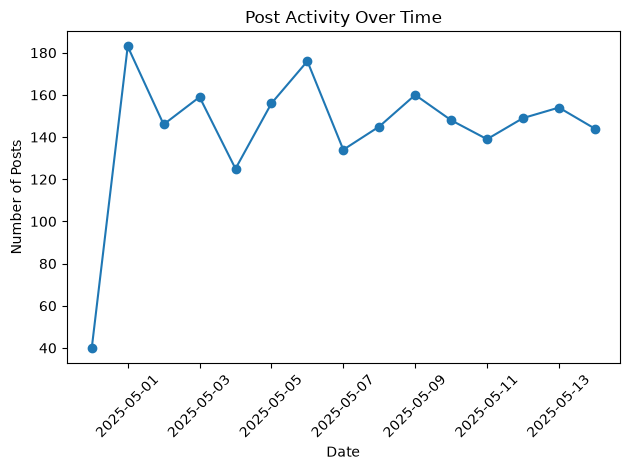

In [199]:
daily_posts.plot(
    kind="line",
    marker="o",
    title="Post Activity Over Time",
    xlabel="Date",
    ylabel="Number of Posts"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

UNDERSTAND POSTS

In [200]:
from collections import Counter
import re

# Combine all post text into one large string
all_text = " ".join(df_posts["text"].astype(str))

# Convert to lowercase
all_text = all_text.lower()

# Extract words
words = re.findall(r"\b[a-zA-Z][a-zA-Z0-9'-]*\b", all_text)

# Count words
word_counts = Counter(words)

# Display the 30 most common words
word_counts.most_common(30)

[('the', 8711),
 ('to', 6767),
 ('and', 5910),
 ('a', 5506),
 ('i', 4914),
 ('it', 3886),
 ('of', 3782),
 ('is', 3347),
 ('for', 3135),
 ('in', 2804),
 ('that', 2692),
 ('with', 2291),
 ('this', 2101),
 ('on', 1967),
 ('ai', 1804),
 ('you', 1746),
 ('or', 1659),
 ('but', 1651),
 ('https', 1431),
 ('not', 1350),
 ('be', 1277),
 ('s', 1217),
 ('are', 1199),
 ('my', 1178),
 ('as', 1172),
 ('if', 1161),
 ('model', 1133),
 ('have', 1098),
 ('can', 1095),
 ('what', 1080)]

In [201]:
Counter(words)

Counter({'the': 8711,
         'to': 6767,
         'and': 5910,
         'a': 5506,
         'i': 4914,
         'it': 3886,
         'of': 3782,
         'is': 3347,
         'for': 3135,
         'in': 2804,
         'that': 2692,
         'with': 2291,
         'this': 2101,
         'on': 1967,
         'ai': 1804,
         'you': 1746,
         'or': 1659,
         'but': 1651,
         'https': 1431,
         'not': 1350,
         'be': 1277,
         's': 1217,
         'are': 1199,
         'my': 1178,
         'as': 1172,
         'if': 1161,
         'model': 1133,
         'have': 1098,
         'can': 1095,
         'what': 1080,
         'like': 1006,
         'just': 928,
         'an': 926,
         'so': 922,
         'models': 904,
         'com': 867,
         'from': 856,
         'at': 815,
         'we': 812,
         'how': 783,
         'was': 782,
         'use': 755,
         'do': 747,
         'by': 740,
         'me': 737,
         'your': 717,
         'ab

In [202]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    min_df=5
)

X = vectorizer.fit_transform(
    df_posts["clean_text"].astype(str)
)

phrases = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

phrase_counts = sorted(
    zip(phrases, counts),
    key=lambda x: x[1],
    reverse=True
)

phrase_counts[:30]

[('llama cpp', np.int64(164)),
 ('open source', np.int64(124)),
 ('30b a3b', np.int64(95)),
 ('tokens second', np.int64(80)),
 ('qwen3 30b', np.int64(76)),
 ('gemini pro', np.int64(73)),
 ('qwen3 235b', np.int64(73)),
 ('gpt 4o', np.int64(71)),
 ('lm studio', np.int64(68)),
 ('235b a22b', np.int64(65)),
 ('qwen3 32b', np.int64(61)),
 ('use ai', np.int64(53)),
 ('deep research', np.int64(51)),
 ('real time', np.int64(50)),
 ('real world', np.int64(50)),
 ('use cases', np.int64(49)),
 ('user input', np.int64(47)),
 ('o4 mini', np.int64(45)),
 ('ai models', np.int64(43)),
 ('use case', np.int64(43)),
 ('don know', np.int64(40)),
 ('language models', np.int64(40)),
 ('local llm', np.int64(40)),
 ('ai agents', np.int64(38)),
 ('kv cache', np.int64(38)),
 ('fine tuning', np.int64(37)),
 ('open ai', np.int64(37)),
 ('prompt eval', np.int64(37)),
 ('let know', np.int64(36)),
 ('sam altman', np.int64(36))]

In [203]:
# Number of posts in each subreddit
subreddit_counts = (
    df_posts["subreddit"]
    .value_counts()
)

print(subreddit_counts)

subreddit
LocalLLaMA     879
OpenAI         675
singularity    401
artificial     203
Name: count, dtype: int64


In [204]:
for subreddit in df_posts["subreddit"].unique():

    subset = df_posts[
        df_posts["subreddit"] == subreddit
    ]

    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=(2, 2),
        min_df=3
    )

    X = vectorizer.fit_transform(
        subset["clean_text"].astype(str)
    )

    phrases = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1

    phrase_counts = sorted(
        zip(phrases, counts),
        key=lambda x: x[1],
        reverse=True
    )

    print("\n" + "=" * 50)
    print(subreddit)
    print("=" * 50)

    print(phrase_counts[:15])


artificial
[('use ai', np.int64(19)), ('ai news', np.int64(15)), ('daily ai', np.int64(15)), ('minute daily', np.int64(14)), ('ai tools', np.int64(13)), ('real world', np.int64(12)), ('gemini pro', np.int64(11)), ('news 2025', np.int64(9)), ('plot promises', np.int64(9)), ('ai actually', np.int64(8)), ('ai agents', np.int64(8)), ('like ai', np.int64(8)), ('new ai', np.int64(8)), ('using ai', np.int64(8)), ('ai models', np.int64(7))]

LocalLLaMA
[('llama cpp', np.int64(164)), ('30b a3b', np.int64(93)), ('open source', np.int64(89)), ('tokens second', np.int64(80)), ('qwen3 30b', np.int64(74)), ('qwen3 235b', np.int64(70)), ('lm studio', np.int64(68)), ('235b a22b', np.int64(62)), ('qwen3 32b', np.int64(60)), ('m3max lcpp', np.int64(50)), ('rtx3090 lcpp', np.int64(46)), ('local llm', np.int64(40)), ('kv cache', np.int64(37)), ('prompt eval', np.int64(37)), ('llama server', np.int64(34))]

singularity
[('gemini pro', np.int64(20)), ('open source', np.int64(19)), ('deep research', np.int6

Engagement analysis

In [205]:
print(df_posts["score"].describe())

count    2158.000000
mean       46.481001
std       138.375264
min         0.000000
25%         1.000000
50%         5.000000
75%        33.000000
max      2304.000000
Name: score, dtype: float64


In [206]:
print(
    df_posts.groupby("subreddit")["score"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

             count        mean  median   max
subreddit                                   
singularity    401  111.720698    32.0  2304
LocalLLaMA     879   36.418658     6.0   820
OpenAI         675   29.420741     2.0  2188
artificial     203   17.906404     2.0   206


In [207]:
print(
    df_posts.groupby("subreddit")["score"]
    .agg(["mean", "median", "max"])
)

                   mean  median   max
subreddit                            
LocalLLaMA    36.418658     6.0   820
OpenAI        29.420741     2.0  2188
artificial    17.906404     2.0   206
singularity  111.720698    32.0  2304


In [208]:
topic_text = df_posts["clean_text"].fillna("").astype(str)

print("Number of posts:", len(topic_text))
print("Empty texts:", (topic_text.str.strip() == "").sum())
print(topic_text.head())

Number of posts: 2158
Empty texts: 0
0                                                                                                                                                                             Incredible. After being pressed for a source for a claim, o3 claims it personally overheard someone say it at a conference in 2018:
11                                                                                                                                                                                                                      Meta is creating AI friends: "The average American has 3 friends, but has demand for 15."
22                                                                                                                                                                                                                                                  Feels sci-fi to watch it "zoom and enhance" while geoguessing
24                                           

In [209]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [210]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85,
    max_features=5000
)

X_tfidf = vectorizer.fit_transform(topic_text)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (2158, 4846)


In [211]:
feature_names = vectorizer.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names[:50])

Number of features: 4846
['00' '000' '000 words' '00001' '01' '02' '03' '0324' '04' '0414' '05'
 '05 06' '06' '07' '08' '09' '10' '10 20' '10 years' '100' '1000' '1000w'
 '102' '1024' '105' '10gb' '10k' '10x' '11' '110' '12' '120' '128' '128gb'
 '128gb ram' '128k' '128k context' '12b' '12gb' '12gb vram' '13' '14'
 '140' '14b' '15' '150' '1500' '15b' '16' '16 gb']


In [212]:
import numpy as np

mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()

top_indices = mean_tfidf.argsort()[::-1][:50]

top_terms = [
    (feature_names[i], mean_tfidf[i])
    for i in top_indices
]

top_terms[:30]

[('ai', np.float64(0.04193946437561347)),
 ('model', np.float64(0.024656733866414884)),
 ('models', np.float64(0.021196220026046236)),
 ('like', np.float64(0.020912549799732512)),
 ('just', np.float64(0.020697527760031843)),
 ('chatgpt', np.float64(0.019017337176758378)),
 ('use', np.float64(0.017519407351790892)),
 ('openai', np.float64(0.015440912516626938)),
 ('using', np.float64(0.014924774495164266)),
 ('new', np.float64(0.013657632008443624)),
 ('gpt', np.float64(0.012661954305413106)),
 ('qwen3', np.float64(0.01265454750232447)),
 ('llm', np.float64(0.012518898865039185)),
 ('think', np.float64(0.011762130629485713)),
 ('ve', np.float64(0.011631625592304356)),
 ('gemini', np.float64(0.011035020860239666)),
 ('local', np.float64(0.010883698765977303)),
 ('people', np.float64(0.010737590056352634)),
 ('want', np.float64(0.010679765039059734)),
 ('know', np.float64(0.010321327964937996)),
 ('time', np.float64(0.010266776873625308)),
 ('best', np.float64(0.01018820440032048)),
 ('op

In [213]:
custom_stopwords = {
    "like", "just", "really", "actually", "probably",
    "think", "know", "want", "good", "make",
    "using", "use", "new", "people", "time",
    "thing", "things", "way", "got", "get",
    "does", "did", "dont", "don't", "can",
    "could", "would", "also", "still",
    "much", "many", "one", "two",
    "see", "look", "say", "said",
    "going", "need", "let", "let's"
}

In [214]:
vectorizer_topic = TfidfVectorizer(
    stop_words=list(custom_stopwords),
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85,
    max_features=5000
)

X_topic = vectorizer_topic.fit_transform(topic_text)

print("New TF-IDF shape:", X_topic.shape)

c:\Users\praharshaanugu\MLprojects\social-media-trend-analyser\venv\Lib\site-packages\sklearn\feature_extraction\text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['don'] not in stop_words.
  warnings.warn(


New TF-IDF shape: (2158, 5000)


In [215]:
feature_names_topic = vectorizer_topic.get_feature_names_out()

mean_tfidf_topic = np.asarray(
    X_topic.mean(axis=0)
).ravel()

top_indices = mean_tfidf_topic.argsort()[::-1][:50]

top_terms_topic = [
    (feature_names_topic[i], mean_tfidf_topic[i])
    for i in top_indices
]

top_terms_topic[:30]

[('the', np.float64(0.07449617591454061)),
 ('to', np.float64(0.0637932575322815)),
 ('and', np.float64(0.05484799313416035)),
 ('it', np.float64(0.04768848236580311)),
 ('of', np.float64(0.04035353745465057)),
 ('is', np.float64(0.03931435955468382)),
 ('for', np.float64(0.0377556271613606)),
 ('ai', np.float64(0.03577705311472221)),
 ('in', np.float64(0.03307775315549844)),
 ('that', np.float64(0.03175114467897752)),
 ('with', np.float64(0.027801194498675384)),
 ('on', np.float64(0.02746876490483014)),
 ('this', np.float64(0.027171922143553743)),
 ('you', np.float64(0.02593868790630826)),
 ('but', np.float64(0.021724188415589617)),
 ('or', np.float64(0.021591866051510887)),
 ('model', np.float64(0.021131439984885796)),
 ('what', np.float64(0.02090313405845025)),
 ('my', np.float64(0.019658452261463566)),
 ('be', np.float64(0.01943293416852173)),
 ('are', np.float64(0.019283972602961583)),
 ('have', np.float64(0.01792536582210524)),
 ('not', np.float64(0.017898113349459118)),
 ('model

In [216]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_tfidf = vectorizer.fit_transform(df_posts["clean_text"])

print("TF-IDF shape:", X_tfidf.shape)
print("Number of features:", len(vectorizer.get_feature_names_out()))

TF-IDF shape: (2158, 5000)
Number of features: 5000


In [217]:
feature_names = vectorizer.get_feature_names_out()

tfidf_scores = X_tfidf.mean(axis=0).A1

top_terms = sorted(
    zip(feature_names, tfidf_scores),
    key=lambda x: x[1],
    reverse=True
)[:50]

top_terms

[('ai', np.float64(0.04262141469484543)),
 ('model', np.float64(0.024305590708472723)),
 ('models', np.float64(0.02110645791439457)),
 ('like', np.float64(0.020717460606077178)),
 ('just', np.float64(0.02061449045770559)),
 ('chatgpt', np.float64(0.019033012185170287)),
 ('use', np.float64(0.017310639985369077)),
 ('openai', np.float64(0.015332926633199469)),
 ('using', np.float64(0.014791430967066867)),
 ('new', np.float64(0.013548830144254382)),
 ('gpt', np.float64(0.012669720469322866)),
 ('qwen3', np.float64(0.012455495693966867)),
 ('llm', np.float64(0.012399458707513375)),
 ('think', np.float64(0.011807548073346186)),
 ('ve', np.float64(0.011524664202622615)),
 ('gemini', np.float64(0.010940991809589724)),
 ('local', np.float64(0.010862859823763032)),
 ('people', np.float64(0.010655772885736289)),
 ('want', np.float64(0.010578334868333775)),
 ('know', np.float64(0.01028235014589495)),
 ('time', np.float64(0.010220023372797465)),
 ('best', np.float64(0.010139788248640948)),
 ('ope

Topic discovery

In [218]:
from sklearn.decomposition import NMF

In [219]:
n_topics = 8

nmf_model = NMF(
    n_components=n_topics,
    random_state=42,
    init="nndsvda",
    max_iter=500
)

W = nmf_model.fit_transform(X_tfidf)
H = nmf_model.components_

print("W shape:", W.shape)
print("H shape:", H.shape)

W shape: (2158, 8)
H shape: (8, 5000)


In [220]:
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()[-15:][::-1]
    
    print(f"\n{'='*50}")
    print(f"TOPIC {topic_idx}")
    print(f"{'='*50}")
    
    print([
        feature_names[i]
        for i in top_indices
    ])


TOPIC 0
['like', 'just', 'think', 'llm', 'want', 've', 'use', 'people', 'don', 'time', 'know', 'tool', 'using', 'prompt', 'make']

TOPIC 1
['ai', 'use ai', 'jobs', 'using ai', 'news', 'google', 'companies', 'human', 'ai news', 'job', 'minute', '2025', 'people', 'daily', 'daily ai']

TOPIC 2
['chatgpt', 'asked', 'image', 'new', 'asked chatgpt', 'original', 'use chatgpt', 'strawberry', 'plus', 'users', 'playing', 'make', 'chatgpt plus', 'ask', 'em']

TOPIC 3
['gpt', 'mini', '4o', 'o4', 'gpt 4o', 'o3', 'o4 mini', 'mini high', 'high', '4o mini', 'plus', 'image', 'chat gpt', 'api', 'chat']

TOPIC 4
['gemini', 'pro', 'gemini pro', '05 06', '06', '05', 'preview', 'pro preview', 'preview 05', 'arena', 'google', 'updated', 'version', 'research', 'deep research']

TOPIC 5
['model', 'models', 'reasoning', 'best', 'open', 'source', 'qwen', 'open source', 'good', 'new', 'local', 'coding', 'language', 'tasks', 'training']

TOPIC 6
['qwen3', 'llama', 'gpu', 'llama cpp', 'cpp', 'cpu', 'run', '30b', '

finding strongest topic for every post

In [221]:
# Find the topic with the highest score for each post
dominant_topic = W.argmax(axis=1)

# Add the topic number to our dataframe
df_posts["topic"] = dominant_topic

# Display the first few posts with their topics
df_posts[["subreddit", "clean_text", "topic"]].head(10)

,subreddit,clean_text,topic
0,artificial,"Incredible. After being pressed for a source for a claim, o3 claims it personally overheard someone say it at a conference in 2018:",3
11,artificial,"Meta is creating AI friends: ""The average American has 3 friends, but has demand for 15.""",1
22,artificial,"Feels sci-fi to watch it ""zoom and enhance"" while geoguessing",7
24,artificial,Brave’s Latest AI Tool Could End Cookie Consent Notices Forever,1
26,artificial,Substrate independence isn't as widely accepted in the scientific community as I reckoned I was writing an argument addressed to those of this community who believe AI will never become conscious. I began with the parallel but easily falsifiable claim that cellular life based on DNA will never b...,0
37,artificial,"Grok DeepSearch vs ChatGPT DeepSearch vs Gemini DeepSearch What were your best experiences? What do you use it for? How often? As a programmer, Gemini by FAR had the best answers to all my questions from designs to library searches to anything else. Grok had the best results for anything not rea...",4
44,artificial,"OpenAI says its GPT-4o update could be ‘uncomfortable, unsettling, and cause distress’",3
55,artificial,Wikipedia announces new AI strategy to “support human editors”,1
56,artificial,"What AI tools have genuinely changed the way you work or create? For me I have been using gen AI tools to help me with tasks like writing emails, UI design, or even just studying. Something like asking ChatGPT or Gemini about the flow of what I'm writing, asking for UI ideas for a specific app f...",1
59,artificial,"Researchers Say the Most Popular Tool for Grading AIs Unfairly Favors Meta, Google, OpenAI",7


In [222]:
topic_counts = df_posts["topic"].value_counts().sort_index()

print(topic_counts)

topic
0    547
1    436
2    155
3    135
4    104
5    338
6    288
7    155
Name: count, dtype: int64


In [223]:
topic_names = {
    0: "General LLM Usage",
    1: "AI News and Jobs",
    2: "ChatGPT",
    3: "GPT Models",
    4: "OpenAI Company",
    5: "Topic 5",
    6: "Topic 6",
    7: "Topic 7"
}

df_posts["topic_name"] = df_posts["topic"].map(topic_names)

df_posts[["clean_text", "topic", "topic_name"]].head(10)

,clean_text,topic,topic_name
0,"Incredible. After being pressed for a source for a claim, o3 claims it personally overheard someone say it at a conference in 2018:",3,GPT Models
11,"Meta is creating AI friends: ""The average American has 3 friends, but has demand for 15.""",1,AI News and Jobs
22,"Feels sci-fi to watch it ""zoom and enhance"" while geoguessing",7,Topic 7
24,Brave’s Latest AI Tool Could End Cookie Consent Notices Forever,1,AI News and Jobs
26,Substrate independence isn't as widely accepted in the scientific community as I reckoned I was writing an argument addressed to those of this community who believe AI will never become conscious. I began with the parallel but easily falsifiable claim that cellular life based on DNA will never b...,0,General LLM Usage
37,"Grok DeepSearch vs ChatGPT DeepSearch vs Gemini DeepSearch What were your best experiences? What do you use it for? How often? As a programmer, Gemini by FAR had the best answers to all my questions from designs to library searches to anything else. Grok had the best results for anything not rea...",4,OpenAI Company
44,"OpenAI says its GPT-4o update could be ‘uncomfortable, unsettling, and cause distress’",3,GPT Models
55,Wikipedia announces new AI strategy to “support human editors”,1,AI News and Jobs
56,"What AI tools have genuinely changed the way you work or create? For me I have been using gen AI tools to help me with tasks like writing emails, UI design, or even just studying. Something like asking ChatGPT or Gemini about the flow of what I'm writing, asking for UI ideas for a specific app f...",1,AI News and Jobs
59,"Researchers Say the Most Popular Tool for Grading AIs Unfairly Favors Meta, Google, OpenAI",7,Topic 7


In [224]:
print(df_posts["topic_name"].value_counts())

topic_name
General LLM Usage    547
AI News and Jobs     436
Topic 5              338
Topic 6              288
Topic 7              155
ChatGPT              155
GPT Models           135
OpenAI Company       104
Name: count, dtype: int64


In [225]:
for topic in sorted(df_posts["topic"].unique()):
    
    print("\n" + "=" * 60)
    print("TOPIC:", topic)
    
    sample_posts = df_posts[df_posts["topic"] == topic]["clean_text"].head(3)
    
    for post in sample_posts:
        print("-", post[:300])


TOPIC: 0
- Substrate independence isn't as widely accepted in the scientific community as I reckoned I was writing an argument addressed to those of this community who believe AI will never become conscious. I began with the parallel but easily falsifiable claim that cellular life based on DNA will never becom
- Modeling Societal Dysfunction Through an Interdisciplinary Lens: Cognitive Bias, Chaos Theory, and Game Theory — Seeking Collaborators or Direction Hello everyone, hope you're doing well! I'm a rising resident physician in anatomic/clinical pathology in the US, with a background in bioinformatics, n
- EasyWhisperUI – Fast, Open Source, and Free Whisper UI for Windows & macOS Hey guys, if you're looking for a fast, open source, and completely free UI for Whisper, please consider trying my app EasyWhisperUI . It features full cross platform GPU acceleration: Vulkan on Windows Metal on macOS I added

TOPIC: 1
- Meta is creating AI friends: "The average American has 3 friends, but

In [226]:
print(df_posts["topic_name"].value_counts())

topic_name
General LLM Usage    547
AI News and Jobs     436
Topic 5              338
Topic 6              288
Topic 7              155
ChatGPT              155
GPT Models           135
OpenAI Company       104
Name: count, dtype: int64


In [227]:
for topic in sorted(df_posts["topic"].unique()):
    print("\n" + "=" * 60)
    print("TOPIC:", topic)

    sample_posts = df_posts[df_posts["topic"] == topic]["clean_text"].head(5)

    for post in sample_posts:
        print("-", post[:250])


TOPIC: 0
- Substrate independence isn't as widely accepted in the scientific community as I reckoned I was writing an argument addressed to those of this community who believe AI will never become conscious. I began with the parallel but easily falsifiable clai
- Modeling Societal Dysfunction Through an Interdisciplinary Lens: Cognitive Bias, Chaos Theory, and Game Theory — Seeking Collaborators or Direction Hello everyone, hope you're doing well! I'm a rising resident physician in anatomic/clinical pathology
- EasyWhisperUI – Fast, Open Source, and Free Whisper UI for Windows & macOS Hey guys, if you're looking for a fast, open source, and completely free UI for Whisper, please consider trying my app EasyWhisperUI . It features full cross platform GPU acce
- Qwen3 vs Absurd Trolley Problems I decided to see how unsloth/Qwen3-30B-A3B-GGUF in thinking mode would handle the full range of Absurd Trolley Problems and here are the answers it gave, what do y'all think? # Prompt: Please answ

Build trend feature

In [228]:
df_posts.columns

Index(['subreddit', 'created_at', 'retrieved_at', 'type', 'text', 'score',
       'post_id', 'parent_id', 'clean_text', 'topic', 'topic_name'],
      dtype='str')

In [229]:
df_posts.columns.tolist()

['subreddit',
 'created_at',
 'retrieved_at',
 'type',
 'text',
 'score',
 'post_id',
 'parent_id',
 'clean_text',
 'topic',
 'topic_name']

In [230]:
df_posts.head()

,subreddit,created_at,retrieved_at,type,text,score,post_id,parent_id,clean_text,topic,topic_name
0,artificial,2025-05-01 10:46:37-05:00,2025-05-01 18:22:20.660913-05:00,post,"Incredible. After being pressed for a source for a claim, o3 claims it personally overheard someone say it at a conference in 2018:\n\n",147,1kcbzf3,NaN,"Incredible. After being pressed for a source for a claim, o3 claims it personally overheard someone say it at a conference in 2018:",3,GPT Models
11,artificial,2025-05-01 10:58:08-05:00,2025-05-01 18:22:20.660913-05:00,post,"Meta is creating AI friends: ""The average American has 3 friends, but has demand for 15.""\n\n",55,1kcc9bp,NaN,"Meta is creating AI friends: ""The average American has 3 friends, but has demand for 15.""",1,AI News and Jobs
22,artificial,2025-05-01 11:45:39-05:00,2025-05-01 18:22:20.660913-05:00,post,"Feels sci-fi to watch it ""zoom and enhance"" while geoguessing\n\n",17,1kcdf7x,NaN,"Feels sci-fi to watch it ""zoom and enhance"" while geoguessing",7,Topic 7
24,artificial,2025-04-30 23:18:17-05:00,2025-05-01 18:22:20.660913-05:00,post,Brave’s Latest AI Tool Could End Cookie Consent Notices Forever\n\n,15,1kc03s7,NaN,Brave’s Latest AI Tool Could End Cookie Consent Notices Forever,1,AI News and Jobs
26,artificial,2025-05-01 03:45:45-05:00,2025-05-01 18:22:20.660913-05:00,post,Substrate independence isn't as widely accepted in the scientific community as I reckoned\n\nI was writing an argument addressed to those of this community who believe AI will never become conscious. I began with the parallel but easily falsifiable claim that cellular life based on DNA will neve...,11,1kc3zgs,NaN,Substrate independence isn't as widely accepted in the scientific community as I reckoned I was writing an argument addressed to those of this community who believe AI will never become conscious. I began with the parallel but easily falsifiable claim that cellular life based on DNA will never b...,0,General LLM Usage


In [231]:
df_posts["date"] = pd.to_datetime(df_posts["created_at"]).dt.date

In [232]:
df_posts[["created_at", "date"]].head(10)

,created_at,date
0,2025-05-01 10:46:37-05:00,2025-05-01
11,2025-05-01 10:58:08-05:00,2025-05-01
22,2025-05-01 11:45:39-05:00,2025-05-01
24,2025-04-30 23:18:17-05:00,2025-04-30
26,2025-05-01 03:45:45-05:00,2025-05-01
37,2025-04-30 22:14:25-05:00,2025-04-30
44,2025-04-30 21:49:15-05:00,2025-04-30
55,2025-05-01 14:25:28-05:00,2025-05-01
56,2025-05-01 11:21:46-05:00,2025-05-01
59,2025-05-01 14:18:08-05:00,2025-05-01


In [233]:
df_posts["date"].value_counts().sort_index()

date
2025-04-30     40
2025-05-01    183
2025-05-02    146
2025-05-03    159
2025-05-04    125
2025-05-05    156
2025-05-06    176
2025-05-07    134
2025-05-08    145
2025-05-09    160
2025-05-10    148
2025-05-11    139
2025-05-12    149
2025-05-13    154
2025-05-14    144
Name: count, dtype: int64

In [234]:
topic_daily = (
    df_posts
    .groupby(["date", "topic", "topic_name"])
    .size()
    .reset_index(name="post_count")
)

In [235]:
topic_daily.head(20)

,date,topic,topic_name,post_count
0,2025-04-30,0,General LLM Usage,8
1,2025-04-30,1,AI News and Jobs,5
2,2025-04-30,3,GPT Models,3
3,2025-04-30,4,OpenAI Company,1
4,2025-04-30,5,Topic 5,9
5,2025-04-30,6,Topic 6,11
6,2025-04-30,7,Topic 7,3
7,2025-05-01,0,General LLM Usage,31
8,2025-05-01,1,AI News and Jobs,35
9,2025-05-01,2,ChatGPT,13


In [236]:
topic_daily.shape

(119, 4)

In [237]:
topic_daily[topic_daily["topic_name"] == "AI News and Jobs"]

,date,topic,topic_name,post_count
1,2025-04-30,1,AI News and Jobs,5
8,2025-05-01,1,AI News and Jobs,35
16,2025-05-02,1,AI News and Jobs,34
24,2025-05-03,1,AI News and Jobs,26
32,2025-05-04,1,AI News and Jobs,24
40,2025-05-05,1,AI News and Jobs,24
48,2025-05-06,1,AI News and Jobs,30
56,2025-05-07,1,AI News and Jobs,27
64,2025-05-08,1,AI News and Jobs,26
72,2025-05-09,1,AI News and Jobs,35


In [238]:
topic_daily = topic_daily.sort_values(
    ["topic", "date"]
).reset_index(drop=True)

topic_daily.head(20)

,date,topic,topic_name,post_count
0,2025-04-30,0,General LLM Usage,8
1,2025-05-01,0,General LLM Usage,31
2,2025-05-02,0,General LLM Usage,28
3,2025-05-03,0,General LLM Usage,43
4,2025-05-04,0,General LLM Usage,37
5,2025-05-05,0,General LLM Usage,36
6,2025-05-06,0,General LLM Usage,42
7,2025-05-07,0,General LLM Usage,32
8,2025-05-08,0,General LLM Usage,38
9,2025-05-09,0,General LLM Usage,49


In [239]:
topic_daily["previous_post_count"] = (
    topic_daily.groupby("topic")["post_count"].shift(1)
)

topic_daily.head(20)

,date,topic,topic_name,post_count,previous_post_count
0,2025-04-30,0,General LLM Usage,8,NaN
1,2025-05-01,0,General LLM Usage,31,8.0
2,2025-05-02,0,General LLM Usage,28,31.0
3,2025-05-03,0,General LLM Usage,43,28.0
4,2025-05-04,0,General LLM Usage,37,43.0
5,2025-05-05,0,General LLM Usage,36,37.0
6,2025-05-06,0,General LLM Usage,42,36.0
7,2025-05-07,0,General LLM Usage,32,42.0
8,2025-05-08,0,General LLM Usage,38,32.0
9,2025-05-09,0,General LLM Usage,49,38.0


In [240]:
topic_daily["growth"] = (
    topic_daily["post_count"]
    - topic_daily["previous_post_count"]
)

In [241]:
topic_daily["growth_rate"] = (
    topic_daily["growth"]
    / topic_daily["previous_post_count"].replace(0, np.nan)
)

In [242]:
topic_daily[
    ["date", "topic_name", "post_count",
     "previous_post_count", "growth", "growth_rate"]
].head(20)

,date,topic_name,post_count,previous_post_count,growth,growth_rate
0,2025-04-30,General LLM Usage,8,NaN,NaN,NaN
1,2025-05-01,General LLM Usage,31,8.0,23.0,2.875000
2,2025-05-02,General LLM Usage,28,31.0,-3.0,-0.096774
3,2025-05-03,General LLM Usage,43,28.0,15.0,0.535714
4,2025-05-04,General LLM Usage,37,43.0,-6.0,-0.139535
5,2025-05-05,General LLM Usage,36,37.0,-1.0,-0.027027
6,2025-05-06,General LLM Usage,42,36.0,6.0,0.166667
7,2025-05-07,General LLM Usage,32,42.0,-10.0,-0.238095
8,2025-05-08,General LLM Usage,38,32.0,6.0,0.187500
9,2025-05-09,General LLM Usage,49,38.0,11.0,0.289474


Calculating trend score

In [243]:
def assign_trend(growth_rate):
    if pd.isna(growth_rate):
        return "Unknown"
    elif growth_rate >= 0.20:
        return "Rising"
    elif growth_rate <= -0.20:
        return "Falling"
    else:
        return "Stable"

topic_daily["trend"] = topic_daily["growth_rate"].apply(assign_trend)

topic_daily.head(20)

,date,topic,topic_name,post_count,previous_post_count,growth,growth_rate,trend
0,2025-04-30,0,General LLM Usage,8,NaN,NaN,NaN,Unknown
1,2025-05-01,0,General LLM Usage,31,8.0,23.0,2.875000,Rising
2,2025-05-02,0,General LLM Usage,28,31.0,-3.0,-0.096774,Stable
3,2025-05-03,0,General LLM Usage,43,28.0,15.0,0.535714,Rising
4,2025-05-04,0,General LLM Usage,37,43.0,-6.0,-0.139535,Stable
5,2025-05-05,0,General LLM Usage,36,37.0,-1.0,-0.027027,Stable
6,2025-05-06,0,General LLM Usage,42,36.0,6.0,0.166667,Stable
7,2025-05-07,0,General LLM Usage,32,42.0,-10.0,-0.238095,Falling
8,2025-05-08,0,General LLM Usage,38,32.0,6.0,0.187500,Stable
9,2025-05-09,0,General LLM Usage,49,38.0,11.0,0.289474,Rising


In [244]:
topic_daily["trend"].value_counts()

trend
Stable     49
Rising     34
Falling    28
Unknown     8
Name: count, dtype: int64

In [245]:
topic_daily["trend"].value_counts(normalize=True) * 100

trend
Stable     41.176471
Rising     28.571429
Falling    23.529412
Unknown     6.722689
Name: proportion, dtype: float64

In [246]:
topic_daily = topic_daily.sort_values(
    ["topic", "date"]
).reset_index(drop=True)

In [247]:
topic_daily["next_day_trend"] = (
    topic_daily.groupby("topic")["trend"].shift(-1)
)

In [248]:
topic_daily[
    ["date", "topic_name", "trend", "next_day_trend"]
].head(20)

,date,topic_name,trend,next_day_trend
0,2025-04-30,General LLM Usage,Unknown,Rising
1,2025-05-01,General LLM Usage,Rising,Stable
2,2025-05-02,General LLM Usage,Stable,Rising
3,2025-05-03,General LLM Usage,Rising,Stable
4,2025-05-04,General LLM Usage,Stable,Stable
5,2025-05-05,General LLM Usage,Stable,Stable
6,2025-05-06,General LLM Usage,Stable,Falling
7,2025-05-07,General LLM Usage,Falling,Stable
8,2025-05-08,General LLM Usage,Stable,Rising
9,2025-05-09,General LLM Usage,Rising,Stable


In [249]:
trend_features = topic_daily.dropna(
    subset=["next_day_trend"]
).copy()

In [250]:
trend_features.shape

(111, 9)

In [251]:
trend_features["next_day_trend"].isna().sum()

np.int64(0)

In [252]:
training_data = trend_features.copy()

training_data = training_data.drop(columns=["topic_name"])

training_data.head()

,date,topic,post_count,previous_post_count,growth,growth_rate,trend,next_day_trend
0,2025-04-30,0,8,NaN,NaN,NaN,Unknown,Rising
1,2025-05-01,0,31,8.0,23.0,2.875000,Rising,Stable
2,2025-05-02,0,28,31.0,-3.0,-0.096774,Stable,Rising
3,2025-05-03,0,43,28.0,15.0,0.535714,Rising,Stable
4,2025-05-04,0,37,43.0,-6.0,-0.139535,Stable,Stable


In [253]:
training_data = training_data.dropna()

print("Shape:", training_data.shape)
print(training_data.isna().sum())

Shape: (103, 8)
date                   0
topic                  0
post_count             0
previous_post_count    0
growth                 0
growth_rate            0
trend                  0
next_day_trend         0
dtype: int64


In [254]:
X = training_data.drop(columns=["next_day_trend"])
y = training_data["next_day_trend"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX:")
print(X.head())

print("\ny:")
print(y.head())

X shape: (103, 7)
y shape: (103,)

X:
         date  topic  post_count  previous_post_count  growth  growth_rate  \
1  2025-05-01      0          31                  8.0    23.0     2.875000   
2  2025-05-02      0          28                 31.0    -3.0    -0.096774   
3  2025-05-03      0          43                 28.0    15.0     0.535714   
4  2025-05-04      0          37                 43.0    -6.0    -0.139535   
5  2025-05-05      0          36                 37.0    -1.0    -0.027027   

    trend  
1  Rising  
2  Stable  
3  Rising  
4  Stable  
5  Stable  

y:
1    Stable
2    Rising
3    Stable
4    Stable
5    Stable
Name: next_day_trend, dtype: str


In [255]:
X["date"] = pd.to_datetime(X["date"])

X["day_of_week"] = X["date"].dt.dayofweek

In [256]:
X[["date", "day_of_week"]].head()

,date,day_of_week
1,2025-05-01,3
2,2025-05-02,4
3,2025-05-03,5
4,2025-05-04,6
5,2025-05-05,0


In [257]:
X = X.drop(columns=["date"])

In [258]:
X.head()

,topic,post_count,previous_post_count,growth,growth_rate,trend,day_of_week
1,0,31,8.0,23.0,2.875000,Rising,3
2,0,28,31.0,-3.0,-0.096774,Stable,4
3,0,43,28.0,15.0,0.535714,Rising,5
4,0,37,43.0,-6.0,-0.139535,Stable,6
5,0,36,37.0,-1.0,-0.027027,Stable,0


In [259]:
X = pd.get_dummies(
    X,
    columns=["trend"],
    dtype=int
)

In [260]:
X.head()

,topic,post_count,previous_post_count,growth,growth_rate,day_of_week,trend_Falling,trend_Rising,trend_Stable
1,0,31,8.0,23.0,2.875000,3,0,1,0
2,0,28,31.0,-3.0,-0.096774,4,0,0,1
3,0,43,28.0,15.0,0.535714,5,0,1,0
4,0,37,43.0,-6.0,-0.139535,6,0,0,1
5,0,36,37.0,-1.0,-0.027027,0,0,0,1


In [261]:
X = pd.get_dummies(
    X,
    columns=["topic"],
    dtype=int
)

In [262]:
print("X shape:", X.shape)

print("\nColumns:")
print(X.columns.tolist())

print("\nFirst 5 rows:")
print(X.head())

X shape: (103, 16)

Columns:
['post_count', 'previous_post_count', 'growth', 'growth_rate', 'day_of_week', 'trend_Falling', 'trend_Rising', 'trend_Stable', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7']

First 5 rows:
   post_count  previous_post_count  growth  growth_rate  day_of_week  \
1          31                  8.0    23.0     2.875000            3   
2          28                 31.0    -3.0    -0.096774            4   
3          43                 28.0    15.0     0.535714            5   
4          37                 43.0    -6.0    -0.139535            6   
5          36                 37.0    -1.0    -0.027027            0   

   trend_Falling  trend_Rising  trend_Stable  topic_0  topic_1  topic_2  \
1              0             1             0        1        0        0   
2              0             0             1        1        0        0   
3              0             1             0        1        0        0   
4       

In [263]:
print("X shape:", X.shape)
print(X.head())
print(X.dtypes)

X shape: (103, 16)
   post_count  previous_post_count  growth  growth_rate  day_of_week  \
1          31                  8.0    23.0     2.875000            3   
2          28                 31.0    -3.0    -0.096774            4   
3          43                 28.0    15.0     0.535714            5   
4          37                 43.0    -6.0    -0.139535            6   
5          36                 37.0    -1.0    -0.027027            0   

   trend_Falling  trend_Rising  trend_Stable  topic_0  topic_1  topic_2  \
1              0             1             0        1        0        0   
2              0             0             1        1        0        0   
3              0             1             0        1        0        0   
4              0             0             1        1        0        0   
5              0             0             1        1        0        0   

   topic_3  topic_4  topic_5  topic_6  topic_7  
1        0        0        0        0        0  

In [264]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in X:")
print(X.isna().sum().sum())

print("\nMissing values in y:")
print(y.isna().sum())

print("\nX data types:")
print(X.dtypes.value_counts())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (103, 16)
y shape: (103,)

Missing values in X:
0

Missing values in y:
0

X data types:
int64      12
float64     3
int32       1
Name: count, dtype: int64

Target distribution:
next_day_trend
Stable     49
Rising     27
Falling    27
Name: count, dtype: int64


In [265]:
print("First date:", trend_features["date"].min())
print("Last date:", trend_features["date"].max())

print("\nNumber of training rows:", len(X))

First date: 2025-04-30
Last date: 2025-05-13

Number of training rows: 103


In [266]:
print(X.index)

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       108, 109, 110, 111, 112, 113, 114, 115, 116, 117],
      dtype='int64', length=103)


Training the model

In [267]:
# Number of rows to use for training
# Get the dates corresponding to the rows used in X and y
model_data = trend_features.dropna(subset=["next_day_trend"]).copy()

# Make sure it is chronological
model_data = model_data.sort_values(["date", "topic"])

# Same 80/20 split
train_size = int(len(model_data) * 0.8)

train_data = model_data.iloc[:train_size]
test_data = model_data.iloc[train_size:]

print("Training period:")
print(train_data["date"].min(), "to", train_data["date"].max())

print("\nTesting period:")
print(test_data["date"].min(), "to", test_data["date"].max())

print("\nTraining rows:", len(train_data))
print("Testing rows:", len(test_data))

Training period:
2025-04-30 to 2025-05-11

Testing period:
2025-05-11 to 2025-05-13

Training rows: 88
Testing rows: 23


In [268]:
print("trend_features:", trend_features.shape)
print("X:", X.shape)
print("y:", y.shape)

print("\nTrend distribution:")
print(trend_features["trend"].value_counts(dropna=False))

print("\nNext-day trend distribution:")
print(trend_features["next_day_trend"].value_counts(dropna=False))

print("\nMissing next_day_trend:")
print(trend_features["next_day_trend"].isna().sum())

trend_features: (111, 9)
X: (103, 16)
y: (103,)

Trend distribution:
trend
Stable     44
Rising     32
Falling    27
Unknown     8
Name: count, dtype: int64

Next-day trend distribution:
next_day_trend
Stable     49
Rising     34
Falling    28
Name: count, dtype: int64

Missing next_day_trend:
0


In [269]:
print(
    trend_features[
        trend_features["next_day_trend"].isna()
    ][["date", "topic", "topic_name", "trend", "next_day_trend"]]
)

Empty DataFrame
Columns: [date, topic, topic_name, trend, next_day_trend]
Index: []


In [270]:
# Create the final dataset used for ML
ml_data = trend_features[
    trend_features["trend"] != "Unknown"
].copy()

print("ML dataset shape:", ml_data.shape)

print("\nTrend distribution:")
print(ml_data["trend"].value_counts())

print("\nDate range:")
print(ml_data["date"].min(), "to", ml_data["date"].max())

ML dataset shape: (103, 9)

Trend distribution:
trend
Stable     44
Rising     32
Falling    27
Name: count, dtype: int64

Date range:
2025-05-01 to 2025-05-13


In [271]:
# Sort by date to make sure the data is chronological
ml_data = ml_data.sort_values("date").copy()

# Number of rows
n = len(ml_data)

# 80% for training
train_size = int(n * 0.8)

# Split the data chronologically
train_data = ml_data.iloc[:train_size].copy()
test_data = ml_data.iloc[train_size:].copy()

print("Training period:",
      train_data["date"].min(),
      "to",
      train_data["date"].max())

print("Testing period:",
      test_data["date"].min(),
      "to",
      test_data["date"].max())

print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

Training period: 2025-05-01 to 2025-05-11
Testing period: 2025-05-11 to 2025-05-13
Training rows: 82
Testing rows: 21


In [272]:
from datetime import date

# Strict time-based split
train_data = ml_data[
    ml_data["date"] < date(2025, 5, 11)
].copy()

test_data = ml_data[
    ml_data["date"] >= date(2025, 5, 11)
].copy()

print("Training period:",
      train_data["date"].min(),
      "to",
      train_data["date"].max())

print("Testing period:",
      test_data["date"].min(),
      "to",
      test_data["date"].max())

print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

Training period: 2025-05-01 to 2025-05-10
Testing period: 2025-05-11 to 2025-05-13
Training rows: 79
Testing rows: 24


In [273]:
overlap = set(train_data["date"]) & set(test_data["date"])

print("Overlapping dates:", overlap)

Overlapping dates: set()


In [274]:
train_data.columns

Index(['date', 'topic', 'topic_name', 'post_count', 'previous_post_count',
       'growth', 'growth_rate', 'trend', 'next_day_trend'],
      dtype='str')

In [275]:
feature_columns = [
    "post_count",
    "previous_post_count",
    "growth",
    "growth_rate",
    "next_day_trend",
    "trend",
    "topic"
]

X_train_raw = train_data[feature_columns].copy()
y_train = train_data["next_day_trend"].copy()

X_test_raw = test_data[feature_columns].copy()
y_test = test_data["next_day_trend"].copy()

print("X_train_raw shape:", X_train_raw.shape)
print("y_train shape:", y_train.shape)

print("X_test_raw shape:", X_test_raw.shape)
print("y_test shape:", y_test.shape)

X_train_raw shape: (79, 7)
y_train shape: (79,)
X_test_raw shape: (24, 7)
y_test shape: (24,)


In [276]:
# Create day-of-week feature
train_data["day_of_week"] = train_data["date"].apply(lambda x: x.weekday())
test_data["day_of_week"] = test_data["date"].apply(lambda x: x.weekday())

print(train_data[["date", "day_of_week"]].head())

           date  day_of_week
1    2025-05-01            3
105  2025-05-01            3
90   2025-05-01            3
75   2025-05-01            3
45   2025-05-01            3


In [277]:
from sklearn.preprocessing import OneHotEncoder

# Create encoder
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

# Categorical columns
categorical_columns = ["trend", "topic"]

# Fit ONLY on training data
encoder.fit(X_train_raw[categorical_columns])

# Transform categorical data
X_train_cat = encoder.transform(
    X_train_raw[categorical_columns]
)

X_test_cat = encoder.transform(
    X_test_raw[categorical_columns]
)

print("Categorical training shape:", X_train_cat.shape)
print("Categorical testing shape:", X_test_cat.shape)

Categorical training shape: (79, 11)
Categorical testing shape: (24, 11)


In [278]:
X_test_raw.columns

Index(['post_count', 'previous_post_count', 'growth', 'growth_rate',
       'next_day_trend', 'trend', 'topic'],
      dtype='str')

In [279]:
import numpy as np

# Numerical columns
numerical_columns = [
    "post_count",
    "previous_post_count",
    "growth",
    "growth_rate",
    "next_day_trend"
]

# Extract numerical data
X_train_num = X_train_raw[numerical_columns].values
X_test_num = X_test_raw[numerical_columns].values

# Combine numerical + encoded categorical features
X_train = np.hstack([
    X_train_num,
    X_train_cat
])

X_test = np.hstack([
    X_test_num,
    X_test_cat
])

print("Final X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Final X_train shape: (79, 16)
Final X_test shape: (24, 16)
y_train shape: (79,)
y_test shape: (24,)


In [280]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
# Exclude the target column from numerical features
numerical_columns = [
    "post_count",
    "previous_post_count",
    "growth",
    "growth_rate"
]

X_train_num = X_train_raw[numerical_columns].astype(float).values
X_test_num = X_test_raw[numerical_columns].astype(float).values

X_train = np.hstack([X_train_num, X_train_cat])
X_test = np.hstack([X_test_num, X_test_cat])

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [281]:
# Make predictions on the unseen test data
y_pred = rf_model.predict(X_test)

print("Predictions shape:", y_pred.shape)
print("Actual shape:", y_test.shape)

print("\nPredictions:")
print(y_pred)

Predictions shape: (24,)
Actual shape: (24,)

Predictions:
['Rising' 'Rising' 'Stable' 'Falling' 'Stable' 'Rising' 'Stable' 'Stable'
 'Stable' 'Stable' 'Stable' 'Rising' 'Falling' 'Stable' 'Stable' 'Rising'
 'Falling' 'Falling' 'Stable' 'Stable' 'Rising' 'Stable' 'Rising' 'Stable']


In [282]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison)

     Actual Predicted
0    Rising    Rising
1   Falling    Rising
2    Stable    Stable
3    Rising   Falling
4    Stable    Stable
5   Falling    Rising
6    Stable    Stable
7    Stable    Stable
8    Stable    Stable
9    Stable    Stable
10   Stable    Stable
11   Rising    Rising
12  Falling   Falling
13   Stable    Stable
14  Falling    Stable
15   Stable    Rising
16   Stable   Falling
17   Rising   Falling
18  Falling    Stable
19   Stable    Stable
20   Stable    Rising
21   Rising    Stable
22   Stable    Rising
23   Stable    Stable


In [283]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.5416666666666666
Accuracy (%): 54.166666666666664


In [284]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Falling", "Stable", "Rising"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 1  2  2]
 [ 1 10  3]
 [ 2  1  2]]


In [285]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    labels=["Falling", "Stable", "Rising"]
)

print(report)

              precision    recall  f1-score   support

     Falling       0.25      0.20      0.22         5
      Stable       0.77      0.71      0.74        14
      Rising       0.29      0.40      0.33         5

    accuracy                           0.54        24
   macro avg       0.43      0.44      0.43        24
weighted avg       0.56      0.54      0.55        24



In [286]:
print(type(encoder))

<class 'sklearn.preprocessing._encoders.OneHotEncoder'>


In [287]:
encoded_columns = encoder.get_feature_names_out(["trend", "topic"])

print(encoded_columns)

['trend_Falling' 'trend_Rising' 'trend_Stable' 'topic_0' 'topic_1'
 'topic_2' 'topic_3' 'topic_4' 'topic_5' 'topic_6' 'topic_7']


In [288]:
encoded_columns = encoder.get_feature_names_out(["trend", "topic"])

feature_names = [
    "post_count",
    "previous_post_count",
    "growth",
    "growth_rate",
    "day_of_week"
] + list(encoded_columns)

print("Number of feature names:", len(feature_names))
print(feature_names)

Number of feature names: 16
['post_count', 'previous_post_count', 'growth', 'growth_rate', 'day_of_week', 'trend_Falling', 'trend_Rising', 'trend_Stable', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7']


In [289]:
model_feature_names = numerical_columns + list(encoded_columns)

if len(model_feature_names) != len(rf_model.feature_importances_):
    raise ValueError(
        "Feature-name count does not match model feature count."
    )

feature_importance = pd.DataFrame({
    "feature": model_feature_names,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance)

                feature  importance
3           growth_rate    0.219236
0            post_count    0.168847
1   previous_post_count    0.167337
2                growth    0.150878
11              topic_4    0.041245
4         trend_Falling    0.039123
14              topic_7    0.029833
13              topic_6    0.027764
5          trend_Rising    0.025816
7               topic_0    0.025348
6          trend_Stable    0.022384
8               topic_1    0.021968
10              topic_3    0.020440
12              topic_5    0.020265
9               topic_2    0.019516


In [290]:
print(feature_importance.to_string(index=False))

            feature  importance
        growth_rate    0.219236
         post_count    0.168847
previous_post_count    0.167337
             growth    0.150878
            topic_4    0.041245
      trend_Falling    0.039123
            topic_7    0.029833
            topic_6    0.027764
       trend_Rising    0.025816
            topic_0    0.025348
       trend_Stable    0.022384
            topic_1    0.021968
            topic_3    0.020440
            topic_5    0.020265
            topic_2    0.019516


In [291]:
ml_data = ml_data.sort_values(
    ["topic", "date"]
).copy()

print(
    ml_data[["date", "topic", "post_count"]].head(15)
)

          date  topic  post_count
1   2025-05-01      0          31
2   2025-05-02      0          28
3   2025-05-03      0          43
4   2025-05-04      0          37
5   2025-05-05      0          36
6   2025-05-06      0          42
7   2025-05-07      0          32
8   2025-05-08      0          38
9   2025-05-09      0          49
10  2025-05-10      0          42
11  2025-05-11      0          38
12  2025-05-12      0          40
13  2025-05-13      0          44
16  2025-05-01      1          35
17  2025-05-02      1          34


In [292]:
ml_data["previous_growth_rate"] = (
    ml_data.groupby("topic")["growth_rate"]
    .shift(1)
)

In [293]:
ml_data["rolling_3day_avg"] = (
    ml_data.groupby("topic")["post_count"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

In [294]:
ml_data["momentum_3day"] = (
    ml_data.groupby("topic")["post_count"]
    .transform(
        lambda x: x.shift(1) - x.shift(4)
    )
)

In [295]:
print(
    ml_data[
        [
            "date",
            "topic",
            "post_count",
            "growth_rate",
            "previous_growth_rate",
            "rolling_3day_avg",
            "momentum_3day"
        ]
    ].head(20)
)

          date  topic  post_count  growth_rate  previous_growth_rate  \
1   2025-05-01      0          31     2.875000                   NaN   
2   2025-05-02      0          28    -0.096774              2.875000   
3   2025-05-03      0          43     0.535714             -0.096774   
4   2025-05-04      0          37    -0.139535              0.535714   
5   2025-05-05      0          36    -0.027027             -0.139535   
6   2025-05-06      0          42     0.166667             -0.027027   
7   2025-05-07      0          32    -0.238095              0.166667   
8   2025-05-08      0          38     0.187500             -0.238095   
9   2025-05-09      0          49     0.289474              0.187500   
10  2025-05-10      0          42    -0.142857              0.289474   
11  2025-05-11      0          38    -0.095238             -0.142857   
12  2025-05-12      0          40     0.052632             -0.095238   
13  2025-05-13      0          44     0.100000              0.05

In [296]:
print(
    ml_data[
        [
            "previous_growth_rate",
            "rolling_3day_avg",
            "momentum_3day"
        ]
    ].isna().sum()
)

previous_growth_rate     8
rolling_3day_avg        24
momentum_3day           32
dtype: int64


In [297]:
print("First date:", ml_data["date"].min())
print("Last date:", ml_data["date"].max())

First date: 2025-05-01
Last date: 2025-05-13


In [298]:
print(
    ml_data.groupby("topic")["date"].min()
)

topic
0    2025-05-01
1    2025-05-01
2    2025-05-02
3    2025-05-01
4    2025-05-01
5    2025-05-01
6    2025-05-01
7    2025-05-01
Name: date, dtype: object


In [299]:
print(topic_daily["date"].min())
print(topic_daily["date"].max())

print(
    topic_daily[
        ["date", "topic", "post_count"]
    ].head(15)
)

2025-04-30
2025-05-14
          date  topic  post_count
0   2025-04-30      0           8
1   2025-05-01      0          31
2   2025-05-02      0          28
3   2025-05-03      0          43
4   2025-05-04      0          37
5   2025-05-05      0          36
6   2025-05-06      0          42
7   2025-05-07      0          32
8   2025-05-08      0          38
9   2025-05-09      0          49
10  2025-05-10      0          42
11  2025-05-11      0          38
12  2025-05-12      0          40
13  2025-05-13      0          44
14  2025-05-14      0          39


In [300]:
topic_daily = topic_daily.sort_values(
    ["topic", "date"]
).copy()

In [301]:
topic_daily["previous_post_count"] = (
    topic_daily.groupby("topic")["post_count"].shift(1)
)

topic_daily["growth"] = (
    topic_daily["post_count"]
    - topic_daily["previous_post_count"]
)

topic_daily["growth_rate"] = (
    topic_daily["growth"]
    / topic_daily["previous_post_count"]
)

In [302]:
def assign_trend(rate):
    if pd.isna(rate):
        return "Unknown"
    elif rate > 0.10:
        return "Rising"
    elif rate < -0.10:
        return "Falling"
    else:
        return "Stable"

In [303]:
topic_daily["trend"] = topic_daily["growth_rate"].apply(assign_trend)

In [304]:
topic_daily["previous_growth_rate"] = (
    topic_daily.groupby("topic")["growth_rate"]
    .shift(1)
)

In [305]:
topic_daily["rolling_3day_avg"] = (
    topic_daily.groupby("topic")["post_count"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

In [306]:
topic_daily["momentum_3day"] = (
    topic_daily.groupby("topic")["post_count"]
    .transform(
        lambda x: x.shift(1) - x.shift(4)
    )
)

In [307]:
topic_daily["next_day_trend"] = (
    topic_daily.groupby("topic")["trend"]
    .shift(-1)
)

In [308]:
topic_daily["day_of_week"] = (
    pd.to_datetime(topic_daily["date"]).dt.dayofweek
)

In [309]:
print(
    topic_daily[
        [
            "date",
            "topic",
            "post_count",
            "growth",
            "growth_rate",
            "trend",
            "previous_growth_rate",
            "rolling_3day_avg",
            "momentum_3day",
            "next_day_trend"
        ]
    ].head(20)
)

          date  topic  post_count  growth  growth_rate    trend  \
0   2025-04-30      0           8     NaN          NaN  Unknown   
1   2025-05-01      0          31    23.0     2.875000   Rising   
2   2025-05-02      0          28    -3.0    -0.096774   Stable   
3   2025-05-03      0          43    15.0     0.535714   Rising   
4   2025-05-04      0          37    -6.0    -0.139535  Falling   
5   2025-05-05      0          36    -1.0    -0.027027   Stable   
6   2025-05-06      0          42     6.0     0.166667   Rising   
7   2025-05-07      0          32   -10.0    -0.238095  Falling   
8   2025-05-08      0          38     6.0     0.187500   Rising   
9   2025-05-09      0          49    11.0     0.289474   Rising   
10  2025-05-10      0          42    -7.0    -0.142857  Falling   
11  2025-05-11      0          38    -4.0    -0.095238   Stable   
12  2025-05-12      0          40     2.0     0.052632   Stable   
13  2025-05-13      0          44     4.0     0.100000   Stabl

In [310]:
print("\nMissing values:")
print(
    topic_daily[
        [
            "previous_growth_rate",
            "rolling_3day_avg",
            "momentum_3day",
            "next_day_trend"
        ]
    ].isna().sum()
)


Missing values:
previous_growth_rate    16
rolling_3day_avg        24
momentum_3day           32
next_day_trend           8
dtype: int64


In [311]:
engineered_data = topic_daily[
    [
        "date",
        "topic",
        "post_count",
        "previous_post_count",
        "growth",
        "growth_rate",
        "day_of_week",
        "trend",
        "previous_growth_rate",
        "rolling_3day_avg",
        "momentum_3day",
        "next_day_trend"
    ]
].copy()

In [312]:
engineered_data = engineered_data.dropna().copy()

In [313]:
print("Engineered ML dataset shape:", engineered_data.shape)

print(
    engineered_data[
        [
            "date",
            "topic",
            "post_count",
            "growth_rate",
            "previous_growth_rate",
            "rolling_3day_avg",
            "momentum_3day",
            "trend",
            "next_day_trend"
        ]
    ].head(15)
)

Engineered ML dataset shape: (79, 12)
          date  topic  post_count  growth_rate  previous_growth_rate  \
4   2025-05-04      0          37    -0.139535              0.535714   
5   2025-05-05      0          36    -0.027027             -0.139535   
6   2025-05-06      0          42     0.166667             -0.027027   
7   2025-05-07      0          32    -0.238095              0.166667   
8   2025-05-08      0          38     0.187500             -0.238095   
9   2025-05-09      0          49     0.289474              0.187500   
10  2025-05-10      0          42    -0.142857              0.289474   
11  2025-05-11      0          38    -0.095238             -0.142857   
12  2025-05-12      0          40     0.052632             -0.095238   
13  2025-05-13      0          44     0.100000              0.052632   
19  2025-05-04      1          24    -0.076923             -0.235294   
20  2025-05-05      1          24     0.000000             -0.076923   
21  2025-05-06      1     

In [314]:
print("\nMissing values:")
print(engineered_data.isna().sum())


Missing values:
date                    0
topic                   0
post_count              0
previous_post_count     0
growth                  0
growth_rate             0
day_of_week             0
trend                   0
previous_growth_rate    0
rolling_3day_avg        0
momentum_3day           0
next_day_trend          0
dtype: int64


In [315]:
train_data = engineered_data[
    engineered_data["date"] < pd.to_datetime("2025-05-11").date()
].copy()

test_data = engineered_data[
    engineered_data["date"] >= pd.to_datetime("2025-05-11").date()
].copy()

print("Training period:",
      train_data["date"].min(),
      "to",
      train_data["date"].max())

print("Testing period:",
      test_data["date"].min(),
      "to",
      test_data["date"].max())

print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

print("Overlapping dates:",
      set(train_data["date"]) & set(test_data["date"]))

Training period: 2025-05-04 to 2025-05-10
Testing period: 2025-05-11 to 2025-05-13
Training rows: 55
Testing rows: 24
Overlapping dates: set()


In [316]:
feature_columns = [
    "post_count",
    "previous_post_count",
    "growth",
    "growth_rate",
    "day_of_week",
    "previous_growth_rate",
    "rolling_3day_avg",
    "momentum_3day",
    "trend",
    "topic"
]

X_train_raw = train_data[feature_columns].copy()
y_train = train_data["next_day_trend"].copy()

X_test_raw = test_data[feature_columns].copy()
y_test = test_data["next_day_trend"].copy()

print("X_train_raw shape:", X_train_raw.shape)
print("y_train shape:", y_train.shape)
print("X_test_raw shape:", X_test_raw.shape)
print("y_test shape:", y_test.shape)

X_train_raw shape: (55, 10)
y_train shape: (55,)
X_test_raw shape: (24, 10)
y_test shape: (24,)


In [317]:
from sklearn.preprocessing import OneHotEncoder

categorical_columns = ["trend", "topic"]

encoder_engineered = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder_engineered.fit_transform(
    X_train_raw[categorical_columns]
)

X_test_cat = encoder_engineered.transform(
    X_test_raw[categorical_columns]
)

print("Categorical training shape:", X_train_cat.shape)
print("Categorical testing shape:", X_test_cat.shape)

Categorical training shape: (55, 11)
Categorical testing shape: (24, 11)


In [318]:
numerical_columns = [
    "post_count",
    "previous_post_count",
    "growth",
    "growth_rate",
    "day_of_week",
    "previous_growth_rate",
    "rolling_3day_avg",
    "momentum_3day"
]

X_train_num = X_train_raw[numerical_columns].values
X_test_num = X_test_raw[numerical_columns].values

X_train = np.hstack([
    X_train_num,
    X_train_cat
])

X_test = np.hstack([
    X_test_num,
    X_test_cat
])

print("Final X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Final X_train shape: (55, 19)
Final X_test shape: (24, 19)
y_train shape: (55,)
y_test shape: (24,)


Improved Random Forest

In [319]:
from sklearn.ensemble import RandomForestClassifier

rf_engineered = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_engineered.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [320]:
y_pred_engineered = rf_engineered.predict(X_test)

print("Predictions shape:", y_pred_engineered.shape)
print("Actual shape:", y_test.shape)

print("\nPredictions:")
print(y_pred_engineered)

Predictions shape: (24,)
Actual shape: (24,)

Predictions:
['Stable' 'Rising' 'Falling' 'Stable' 'Stable' 'Falling' 'Rising' 'Stable'
 'Rising' 'Falling' 'Rising' 'Rising' 'Falling' 'Falling' 'Rising'
 'Falling' 'Stable' 'Falling' 'Rising' 'Rising' 'Falling' 'Falling'
 'Rising' 'Stable']


In [321]:
from sklearn.metrics import accuracy_score

accuracy_engineered = accuracy_score(
    y_test,
    y_pred_engineered
)

print("Engineered Model Accuracy:", accuracy_engineered)
print(
    "Engineered Model Accuracy (%):",
    accuracy_engineered * 100
)

Engineered Model Accuracy: 0.4166666666666667
Engineered Model Accuracy (%): 41.66666666666667


In [322]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_engineered
    )
)

              precision    recall  f1-score   support

     Falling       0.56      0.71      0.62         7
      Rising       0.22      0.25      0.24         8
      Stable       0.50      0.33      0.40         9

    accuracy                           0.42        24
   macro avg       0.43      0.43      0.42        24
weighted avg       0.42      0.42      0.41        24



In [323]:
print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_engineered,
        labels=["Falling", "Stable", "Rising"]
    )
)

Confusion Matrix:
[[5 1 1]
 [0 3 6]
 [4 2 2]]


In [324]:
feature_names = (
    numerical_columns
    + encoder_engineered.get_feature_names_out(
        categorical_columns
    ).tolist()
)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_engineered.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(feature_importance)

                 feature  importance
5   previous_growth_rate    0.155974
3            growth_rate    0.145953
2                 growth    0.112732
7          momentum_3day    0.092564
6       rolling_3day_avg    0.092251
0             post_count    0.088447
1    previous_post_count    0.081842
4            day_of_week    0.076112
9           trend_Rising    0.020086
12               topic_1    0.017194
10          trend_Stable    0.017098
8          trend_Falling    0.016069
17               topic_6    0.015811
13               topic_2    0.014676
18               topic_7    0.011686
14               topic_3    0.011078
16               topic_5    0.010480
11               topic_0    0.010062
15               topic_4    0.009886


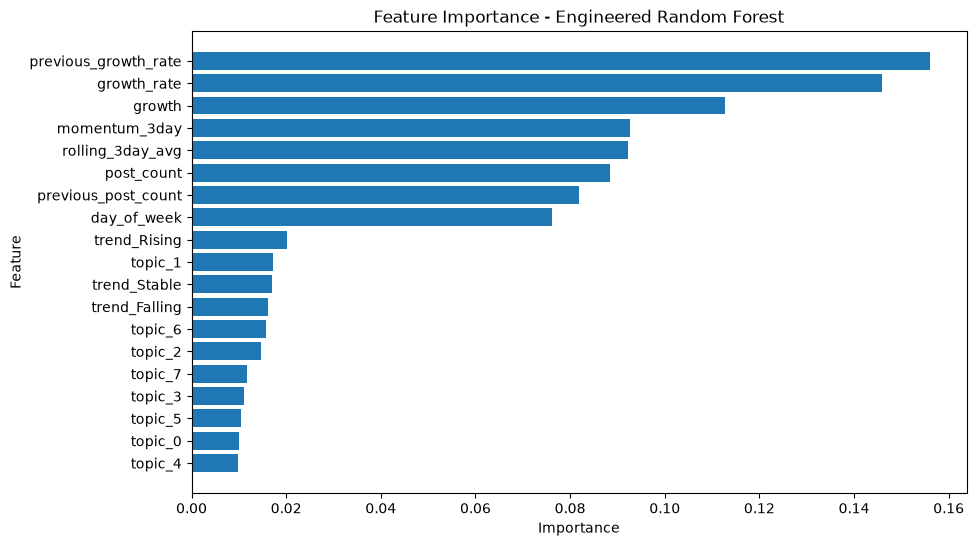

In [325]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Engineered Random Forest")
plt.gca().invert_yaxis()

plt.show()

In [326]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=3,
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [327]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Accuracy:", dt_accuracy)
print(
    "Decision Tree Accuracy (%):",
    dt_accuracy * 100
)

Decision Tree Accuracy: 0.4166666666666667
Decision Tree Accuracy (%): 41.66666666666667


In [328]:
print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

              precision    recall  f1-score   support

     Falling       0.43      0.43      0.43         7
      Rising       0.38      0.62      0.48         8
      Stable       0.50      0.22      0.31         9

    accuracy                           0.42        24
   macro avg       0.44      0.43      0.40        24
weighted avg       0.44      0.42      0.40        24



In [329]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

tscv = TimeSeriesSplit(n_splits=4)

scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):

    X_train_cv = X.iloc[train_idx] if hasattr(X, "iloc") else X[train_idx]
    X_test_cv = X.iloc[test_idx] if hasattr(X, "iloc") else X[test_idx]

    y_train_cv = y.iloc[train_idx] if hasattr(y, "iloc") else y[train_idx]
    y_test_cv = y.iloc[test_idx] if hasattr(y, "iloc") else y[test_idx]

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_train_cv, y_train_cv)

    predictions = model.predict(X_test_cv)

    accuracy = accuracy_score(
        y_test_cv,
        predictions
    )

    scores.append(accuracy)

    print(f"Fold {fold} accuracy: {accuracy:.4f}")

print("\nAverage CV accuracy:", sum(scores) / len(scores))

Fold 1 accuracy: 0.4500
Fold 2 accuracy: 0.2500
Fold 3 accuracy: 0.4000
Fold 4 accuracy: 0.4000

Average CV accuracy: 0.375


In [330]:
print(X.shape)
print(y.shape)

(103, 16)
(103,)


In [331]:
from sklearn.metrics import accuracy_score, classification_report

# Persistence baseline:
# Assume tomorrow's trend will be the same as today's trend

y_pred_persistence = ml_data.loc[
    y.index,
    "trend"
]

accuracy_persistence = accuracy_score(
    y,
    y_pred_persistence
)

print("Persistence Baseline Accuracy:",
      accuracy_persistence)

print("Persistence Baseline Accuracy (%):",
      accuracy_persistence * 100)

print("\nClassification Report:")
print(
    classification_report(
        y,
        y_pred_persistence
    )
)

Persistence Baseline Accuracy: 0.2912621359223301
Persistence Baseline Accuracy (%): 29.126213592233007

Classification Report:
              precision    recall  f1-score   support

     Falling       0.15      0.15      0.15        27
      Rising       0.06      0.07      0.07        27
      Stable       0.55      0.49      0.52        49

    accuracy                           0.29       103
   macro avg       0.25      0.24      0.24       103
weighted avg       0.31      0.29      0.30       103



In [332]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("Majority Baseline Accuracy:",
      accuracy_score(y_test, y_pred_dummy))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dummy
    )
)

Majority Baseline Accuracy: 0.2916666666666667

Classification Report:
              precision    recall  f1-score   support

     Falling       0.29      1.00      0.45         7
      Rising       0.00      0.00      0.00         8
      Stable       0.00      0.00      0.00         9

    accuracy                           0.29        24
   macro avg       0.10      0.33      0.15        24
weighted avg       0.09      0.29      0.13        24



c:\Users\praharshaanugu\MLprojects\social-media-trend-analyser\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\praharshaanugu\MLprojects\social-media-trend-analyser\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\praharshaanugu\MLprojects\social-media-trend-analyser\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

In [333]:
print("Unique dates:", ml_data["date"].nunique())

print(
    sorted(
        ml_data["date"].unique()
    )
)

Unique dates: 13
[datetime.date(2025, 5, 1), datetime.date(2025, 5, 2), datetime.date(2025, 5, 3), datetime.date(2025, 5, 4), datetime.date(2025, 5, 5), datetime.date(2025, 5, 6), datetime.date(2025, 5, 7), datetime.date(2025, 5, 8), datetime.date(2025, 5, 9), datetime.date(2025, 5, 10), datetime.date(2025, 5, 11), datetime.date(2025, 5, 12), datetime.date(2025, 5, 13)]


In [334]:
print(
    ml_data.groupby("date").size()
)

date
2025-05-01    7
2025-05-02    8
2025-05-03    8
2025-05-04    8
2025-05-05    8
2025-05-06    8
2025-05-07    8
2025-05-08    8
2025-05-09    8
2025-05-10    8
2025-05-11    8
2025-05-12    8
2025-05-13    8
dtype: int64


In [335]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import pandas as pd

# Make sure dates are sorted
ml_data_sorted = ml_data.sort_values(
    ["date", "topic"]
).reset_index(drop=True)

# Dates in chronological order
dates = sorted(
    ml_data_sorted["date"].unique()
)

results = []

# Start testing from the 6th date
for i in range(5, len(dates)):

    train_dates = dates[:i]
    test_date = dates[i]

    train_mask = ml_data_sorted["date"].isin(train_dates)
    test_mask = ml_data_sorted["date"] == test_date

    train_rows = ml_data_sorted[train_mask]
    test_rows = ml_data_sorted[test_mask]

    # Get the corresponding rows from X
    train_indices = train_rows.index
    test_indices = test_rows.index

    X_train_date = X.iloc[train_indices]
    X_test_date = X.iloc[test_indices]

    y_train_date = y.iloc[train_indices]
    y_test_date = y.iloc[test_indices]

    # Train model
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(
        X_train_date,
        y_train_date
    )

    predictions = model.predict(
        X_test_date
    )

    accuracy = accuracy_score(
        y_test_date,
        predictions
    )

    balanced_acc = balanced_accuracy_score(
        y_test_date,
        predictions
    )

    results.append({
        "test_date": test_date,
        "train_rows": len(train_rows),
        "test_rows": len(test_rows),
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc
    })

# Convert results to DataFrame
date_cv_results = pd.DataFrame(results)

print(date_cv_results)

print("\nAverage Accuracy:",
      date_cv_results["accuracy"].mean())

print("Average Balanced Accuracy:",
      date_cv_results["balanced_accuracy"].mean())

c:\Users\praharshaanugu\MLprojects\social-media-trend-analyser\venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\praharshaanugu\MLprojects\social-media-trend-analyser\venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


    test_date  train_rows  test_rows  accuracy  balanced_accuracy
0  2025-05-06          39          8     0.375           0.500000
1  2025-05-07          47          8     0.125           0.166667
2  2025-05-08          55          8     0.750           0.555556
3  2025-05-09          63          8     0.250           0.222222
4  2025-05-10          71          8     0.375           0.583333
5  2025-05-11          79          8     0.375           0.366667
6  2025-05-12          87          8     0.375           0.333333
7  2025-05-13          95          8     0.375           0.444444

Average Accuracy: 0.375
Average Balanced Accuracy: 0.39652777777777776


In [336]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)
import pandas as pd

ml_data_sorted = ml_data.sort_values(
    ["date", "topic"]
).reset_index(drop=True)

dates = sorted(ml_data_sorted["date"].unique())

all_actual = []
all_predictions = []

# Expanding-window validation
for i in range(5, len(dates)):

    train_dates = dates[:i]
    test_date = dates[i]

    train_mask = ml_data_sorted["date"].isin(train_dates)
    test_mask = ml_data_sorted["date"] == test_date

    train_rows = ml_data_sorted[train_mask]
    test_rows = ml_data_sorted[test_mask]

    train_indices = train_rows.index
    test_indices = test_rows.index

    X_train_date = X.iloc[train_indices]
    X_test_date = X.iloc[test_indices]

    y_train_date = y.iloc[train_indices]
    y_test_date = y.iloc[test_indices]

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(
        X_train_date,
        y_train_date
    )

    predictions = model.predict(X_test_date)

    all_actual.extend(y_test_date.tolist())
    all_predictions.extend(predictions.tolist())


# Convert to Series
all_actual = pd.Series(all_actual)
all_predictions = pd.Series(all_predictions)

# -----------------------------
# Overall metrics
# -----------------------------

accuracy = accuracy_score(
    all_actual,
    all_predictions
)

balanced_accuracy = balanced_accuracy_score(
    all_actual,
    all_predictions
)

print("Overall Accuracy:",
      accuracy)

print("Overall Accuracy (%):",
      accuracy * 100)

print("Balanced Accuracy:",
      balanced_accuracy)

print("Balanced Accuracy (%):",
      balanced_accuracy * 100)


# -----------------------------
# Classification report
# -----------------------------

print("\nClassification Report:")
print(
    classification_report(
        all_actual,
        all_predictions,
        labels=["Falling", "Rising", "Stable"],
        zero_division=0
    )
)


# -----------------------------
# Confusion Matrix
# -----------------------------

cm = confusion_matrix(
    all_actual,
    all_predictions,
    labels=["Falling", "Rising", "Stable"]
)

print("\nConfusion Matrix:")
print(cm)

Overall Accuracy: 0.375
Overall Accuracy (%): 37.5
Balanced Accuracy: 0.3910818713450292
Balanced Accuracy (%): 39.10818713450292

Classification Report:
              precision    recall  f1-score   support

     Falling       0.37      0.33      0.35        21
      Rising       0.40      0.63      0.49        19
      Stable       0.33      0.21      0.26        24

    accuracy                           0.38        64
   macro avg       0.37      0.39      0.37        64
weighted avg       0.36      0.38      0.36        64


Confusion Matrix:
[[ 7  5  9]
 [ 6 12  1]
 [ 6 13  5]]


In [337]:
print(
    ml_data.groupby("trend")["growth_rate"].describe()
)

         count      mean       std       min       25%       50%       75%  \
trend                                                                        
Falling   27.0 -0.388932  0.137001 -0.666667 -0.500000 -0.347826 -0.285714   
Rising    32.0  1.575155  1.922694  0.200000  0.386538  0.800000  1.770833   
Stable    44.0 -0.036651  0.109122 -0.193548 -0.117788 -0.056548  0.007143   

              max  
trend              
Falling -0.222222  
Rising   8.000000  
Stable   0.187500  


In [338]:
print(
    ml_data.groupby("next_day_trend")["growth_rate"].describe()
)

                count      mean       std       min       25%       50%  \
next_day_trend                                                            
Falling          27.0  0.736222  1.474092 -0.590909 -0.134615  0.171429   
Rising           27.0  0.160627  1.657809 -0.636364 -0.392308 -0.230769   
Stable           49.0  0.287270  1.038932 -0.666667 -0.166667  0.000000   

                     75%       max  
next_day_trend                      
Falling         1.250000  6.333333  
Rising         -0.018519  8.000000  
Stable          0.289474  6.000000  


In [339]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import pandas as pd

ml_data_sorted = ml_data.sort_values(
    ["date", "topic"]
).reset_index(drop=True)

dates = sorted(ml_data_sorted["date"].unique())

lr_results = []

for i in range(5, len(dates)):

    train_dates = dates[:i]
    test_date = dates[i]

    train_mask = ml_data_sorted["date"].isin(train_dates)
    test_mask = ml_data_sorted["date"] == test_date

    train_rows = ml_data_sorted[train_mask]
    test_rows = ml_data_sorted[test_mask]

    train_indices = train_rows.index
    test_indices = test_rows.index

    X_train_date = X.iloc[train_indices]
    X_test_date = X.iloc[test_indices]

    y_train_date = y.iloc[train_indices]
    y_test_date = y.iloc[test_indices]

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(
        X_train_date,
        y_train_date
    )

    predictions = model.predict(X_test_date)

    accuracy = accuracy_score(
        y_test_date,
        predictions
    )

    balanced_acc = balanced_accuracy_score(
        y_test_date,
        predictions
    )

    lr_results.append({
        "test_date": test_date,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc
    })

lr_results = pd.DataFrame(lr_results)

print(lr_results)

print("\nAverage Accuracy:",
      lr_results["accuracy"].mean())

print("Average Balanced Accuracy:",
      lr_results["balanced_accuracy"].mean())

c:\Users\praharshaanugu\MLprojects\social-media-trend-analyser\venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\praharshaanugu\MLprojects\social-media-trend-analyser\venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


    test_date  accuracy  balanced_accuracy
0  2025-05-06     0.375           0.500000
1  2025-05-07     0.250           0.250000
2  2025-05-08     0.625           0.472222
3  2025-05-09     0.375           0.388889
4  2025-05-10     0.250           0.333333
5  2025-05-11     0.375           0.500000
6  2025-05-12     0.250           0.222222
7  2025-05-13     0.500           0.555556

Average Accuracy: 0.375
Average Balanced Accuracy: 0.40277777777777773


In [340]:
# Make sure everything is sorted consistently
ml_data_sorted = ml_data.sort_values(
    ["date", "topic"]
).reset_index(drop=True)

# May 13 = latest date whose tomorrow we want to predict
forecast_date = pd.to_datetime("2025-05-13").date()

# Training = dates BEFORE May 13
train_mask = ml_data_sorted["date"] < forecast_date

# Forecast rows = May 13
forecast_mask = ml_data_sorted["date"] == forecast_date

train_rows = ml_data_sorted[train_mask]
forecast_rows = ml_data_sorted[forecast_mask]

print("Training period:",
      train_rows["date"].min(),
      "to",
      train_rows["date"].max())

print("Forecast date:",
      forecast_rows["date"].min())

print("Training rows:",
      len(train_rows))

print("Forecast rows:",
      len(forecast_rows))

print("\nForecast topics:")
print(
    forecast_rows[
        ["date", "topic", "topic_name", "post_count", "trend"]
    ]
)

Training period: 2025-05-01 to 2025-05-12
Forecast date: 2025-05-13
Training rows: 95
Forecast rows: 8

Forecast topics:
           date  topic         topic_name  post_count    trend
95   2025-05-13      0  General LLM Usage          44   Stable
96   2025-05-13      1   AI News and Jobs          41   Stable
97   2025-05-13      2            ChatGPT          10  Falling
98   2025-05-13      3         GPT Models          10   Stable
99   2025-05-13      4     OpenAI Company           5  Falling
100  2025-05-13      5            Topic 5          23   Stable
101  2025-05-13      6            Topic 6          11   Stable
102  2025-05-13      7            Topic 7          10   Rising


In [341]:
train_indices = train_rows.index
forecast_indices = forecast_rows.index

X_train_final = X.iloc[train_indices]
y_train_final = y.iloc[train_indices]

X_forecast = X.iloc[forecast_indices]

print("X_train_final:", X_train_final.shape)
print("y_train_final:", y_train_final.shape)
print("X_forecast:", X_forecast.shape)

X_train_final: (95, 16)
y_train_final: (95,)
X_forecast: (8, 16)


In [354]:
ml_data_sorted = ml_data_sorted.sort_values(
    ["date", "topic"]
).reset_index(drop=True)

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

print("ML data:", ml_data_sorted.shape)
print("X:", X.shape)
print("y:", y.shape)

ML data: (103, 12)
X: (103, 16)
y: (103,)


In [355]:
forecast_date = pd.to_datetime("2025-05-13").date()

train_mask = ml_data_sorted["date"] < forecast_date
forecast_mask = ml_data_sorted["date"] == forecast_date

print("Training rows:", train_mask.sum())
print("Forecast rows:", forecast_mask.sum())

print(
    "Training period:",
    ml_data_sorted.loc[train_mask, "date"].min(),
    "to",
    ml_data_sorted.loc[train_mask, "date"].max()
)

print(
    "Forecast input date:",
    ml_data_sorted.loc[forecast_mask, "date"].unique()
)

Training rows: 95
Forecast rows: 8
Training period: 2025-05-01 to 2025-05-12
Forecast input date: [datetime.date(2025, 5, 13)]


In [356]:
import numpy as np

train_indices = np.flatnonzero(train_mask)
forecast_indices = np.flatnonzero(forecast_mask)

X_train_final = X.iloc[train_indices]
y_train_final = y.iloc[train_indices]

X_forecast = X.iloc[forecast_indices]

print("Training X:", X_train_final.shape)
print("Training y:", y_train_final.shape)
print("Forecast X:", X_forecast.shape)

Training X: (95, 16)
Training y: (95,)
Forecast X: (8, 16)


In [357]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

final_model.fit(
    X_train_final,
    y_train_final
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [358]:
forecast_predictions = final_model.predict(X_forecast)

print(forecast_predictions)

['Rising' 'Rising' 'Rising' 'Stable' 'Rising' 'Rising' 'Rising' 'Stable']


In [359]:
forecast_rows = ml_data_sorted.loc[
    forecast_mask,
    [
        "date",
        "topic",
        "topic_name",
        "post_count",
        "previous_post_count",
        "growth",
        "growth_rate",
        "trend"
    ]
].copy().reset_index(drop=True)

In [360]:
print(forecast_rows.columns.tolist())

['date', 'topic', 'topic_name', 'post_count', 'previous_post_count', 'growth', 'growth_rate', 'trend']


In [361]:
forecast_result = forecast_rows.copy()

forecast_result = forecast_result.rename(
    columns={
        "date": "current_date",
        "trend": "current_trend"
    }
)

forecast_result["predicted_next_day_trend"] = forecast_predictions

In [362]:
print(
    forecast_result[
        [
            "current_date",
            "topic",
            "topic_name",
            "post_count",
            "previous_post_count",
            "growth",
            "growth_rate",
            "current_trend",
            "predicted_next_day_trend"
        ]
    ].to_string(index=False)
)

current_date  topic        topic_name  post_count  previous_post_count  growth  growth_rate current_trend predicted_next_day_trend
  2025-05-13      0 General LLM Usage          44                 40.0     4.0     0.100000        Stable                   Rising
  2025-05-13      1  AI News and Jobs          41                 35.0     6.0     0.171429        Stable                   Rising
  2025-05-13      2           ChatGPT          10                 14.0    -4.0    -0.285714       Falling                   Rising
  2025-05-13      3        GPT Models          10                 10.0     0.0     0.000000        Stable                   Stable
  2025-05-13      4    OpenAI Company           5                  7.0    -2.0    -0.285714       Falling                   Rising
  2025-05-13      5           Topic 5          23                 24.0    -1.0    -0.041667        Stable                   Rising
  2025-05-13      6           Topic 6          11                 12.0    -1.0    -

In [363]:
actual_may14 = (
    ml_data_sorted.loc[
        forecast_mask,
        "next_day_trend"
    ]
    .reset_index(drop=True)
)

forecast_result["actual_next_day_trend"] = actual_may14

In [364]:
forecast_result["correct"] = (
    forecast_result["predicted_next_day_trend"]
    ==
    forecast_result["actual_next_day_trend"]
)

In [365]:
print(
    forecast_result[
        [
            "topic_name",
            "post_count",
            "growth_rate",
            "current_trend",
            "predicted_next_day_trend",
            "actual_next_day_trend",
            "correct"
        ]
    ].to_string(index=False)
)

       topic_name  post_count  growth_rate current_trend predicted_next_day_trend actual_next_day_trend  correct
General LLM Usage          44     0.100000        Stable                   Rising                Stable    False
 AI News and Jobs          41     0.171429        Stable                   Rising               Falling    False
          ChatGPT          10    -0.285714       Falling                   Rising                Stable    False
       GPT Models          10     0.000000        Stable                   Stable                Stable     True
   OpenAI Company           5    -0.285714       Falling                   Rising                Stable    False
          Topic 5          23    -0.041667        Stable                   Rising                Rising     True
          Topic 6          11    -0.083333        Stable                   Rising                Rising     True
          Topic 7          10     0.428571        Rising                   Stable               

In [366]:
may14_accuracy = forecast_result["correct"].mean()

print("May 14 Forecast Accuracy:", may14_accuracy)

print(
    "May 14 Forecast Accuracy (%):",
    round(may14_accuracy * 100, 2)
)

May 14 Forecast Accuracy: 0.5
May 14 Forecast Accuracy (%): 50.0


Trend Intelligence

In [367]:
trend_intelligence = forecast_result.copy()

# Convert predicted direction into a numeric signal
direction_map = {
    "Rising": 1,
    "Stable": 0,
    "Falling": -1
}

trend_intelligence["direction_signal"] = (
    trend_intelligence["predicted_next_day_trend"]
    .map(direction_map)
)

# Show the information we currently have
print(
    trend_intelligence[
        [
            "topic_name",
            "post_count",
            "growth_rate",
            "current_trend",
            "predicted_next_day_trend",
            "direction_signal"
        ]
    ].to_string(index=False)
)

       topic_name  post_count  growth_rate current_trend predicted_next_day_trend  direction_signal
General LLM Usage          44     0.100000        Stable                   Rising                 1
 AI News and Jobs          41     0.171429        Stable                   Rising                 1
          ChatGPT          10    -0.285714       Falling                   Rising                 1
       GPT Models          10     0.000000        Stable                   Stable                 0
   OpenAI Company           5    -0.285714       Falling                   Rising                 1
          Topic 5          23    -0.041667        Stable                   Rising                 1
          Topic 6          11    -0.083333        Stable                   Rising                 1
          Topic 7          10     0.428571        Rising                   Stable                 0


Model Probability

In [368]:
forecast_probabilities = final_model.predict_proba(X_forecast)

print("Model classes:")
print(final_model.classes_)

print("\nProbability shape:")
print(forecast_probabilities.shape)

Model classes:
['Falling' 'Rising' 'Stable']

Probability shape:
(8, 3)


In [369]:
for i, class_name in enumerate(final_model.classes_):
    trend_intelligence[f"{class_name}_probability"] = (
        forecast_probabilities[:, i]
    )

In [370]:
print(
    trend_intelligence[
        [
            "topic_name",
            "growth_rate",
            "predicted_next_day_trend",
            "Falling_probability",
            "Rising_probability",
            "Stable_probability"
        ]
    ].to_string(index=False)
)

       topic_name  growth_rate predicted_next_day_trend  Falling_probability  Rising_probability  Stable_probability
General LLM Usage     0.100000                   Rising                0.280               0.405               0.315
 AI News and Jobs     0.171429                   Rising                0.160               0.450               0.390
          ChatGPT    -0.285714                   Rising                0.365               0.370               0.265
       GPT Models     0.000000                   Stable                0.320               0.290               0.390
   OpenAI Company    -0.285714                   Rising                0.085               0.565               0.350
          Topic 5    -0.041667                   Rising                0.265               0.455               0.280
          Topic 6    -0.083333                   Rising                0.080               0.490               0.430
          Topic 7     0.428571                   Stable         

In [371]:
def predicted_probability(row):
    predicted = row["predicted_next_day_trend"]
    return row[f"{predicted}_probability"]


trend_intelligence["prediction_probability"] = (
    trend_intelligence.apply(
        predicted_probability,
        axis=1
    )
)

In [372]:
trend_intelligence["prediction_probability_percent"] = (
    trend_intelligence["prediction_probability"] * 100
).round(2)

In [373]:
print(
    trend_intelligence[
        [
            "topic_name",
            "post_count",
            "growth_rate",
            "current_trend",
            "predicted_next_day_trend",
            "prediction_probability_percent"
        ]
    ]
    .sort_values(
        "prediction_probability_percent",
        ascending=False
    )
    .to_string(index=False)
)

       topic_name  post_count  growth_rate current_trend predicted_next_day_trend  prediction_probability_percent
   OpenAI Company           5    -0.285714       Falling                   Rising                            56.5
          Topic 6          11    -0.083333        Stable                   Rising                            49.0
          Topic 7          10     0.428571        Rising                   Stable                            48.0
          Topic 5          23    -0.041667        Stable                   Rising                            45.5
 AI News and Jobs          41     0.171429        Stable                   Rising                            45.0
General LLM Usage          44     0.100000        Stable                   Rising                            40.5
       GPT Models          10     0.000000        Stable                   Stable                            39.0
          ChatGPT          10    -0.285714       Falling                   Rising       

In [375]:
probability_columns = [
    "Falling_probability",
    "Rising_probability",
    "Stable_probability"
]

def calculate_margin(row):
    probs = sorted(
        [row[col] for col in probability_columns],
        reverse=True
    )

    return probs[0] - probs[1]


trend_intelligence["prediction_margin"] = (
    trend_intelligence.apply(
        calculate_margin,
        axis=1
    )
)

trend_intelligence["prediction_margin_percent"] = (
    trend_intelligence["prediction_margin"] * 100
).round(2)

In [376]:
print(
    trend_intelligence[
        [
            "topic_name",
            "growth_rate",
            "predicted_next_day_trend",
            "prediction_probability_percent",
            "prediction_margin_percent"
        ]
    ]
    .sort_values(
        "prediction_margin_percent",
        ascending=False
    )
    .to_string(index=False)
)

       topic_name  growth_rate predicted_next_day_trend  prediction_probability_percent  prediction_margin_percent
          Topic 7     0.428571                   Stable                            48.0                       21.5
   OpenAI Company    -0.285714                   Rising                            56.5                       21.5
          Topic 5    -0.041667                   Rising                            45.5                       17.5
General LLM Usage     0.100000                   Rising                            40.5                        9.0
       GPT Models     0.000000                   Stable                            39.0                        7.0
 AI News and Jobs     0.171429                   Rising                            45.0                        6.0
          Topic 6    -0.083333                   Rising                            49.0                        6.0
          ChatGPT    -0.285714                   Rising                         

In [377]:
def classify_trend_transition(row):

    current = row["current_trend"]
    predicted = row["predicted_next_day_trend"]

    if current == "Falling" and predicted == "Rising":
        return "Possible Rebound"

    elif current == "Stable" and predicted == "Rising":
        return "Emerging Trend"

    elif current == "Rising" and predicted == "Rising":
        return "Continuing Rise"

    elif current == "Rising" and predicted == "Stable":
        return "Stabilizing"

    elif current == "Stable" and predicted == "Stable":
        return "Steady"

    elif current == "Falling" and predicted == "Stable":
        return "Recovering / Stabilizing"

    elif predicted == "Falling" and current == "Rising":
        return "Cooling Down"

    elif predicted == "Falling" and current == "Stable":
        return "Possible Decline"

    elif current == "Falling" and predicted == "Falling":
        return "Continuing Decline"

    else:
        return "Mixed"


trend_intelligence["trend_signal"] = (
    trend_intelligence.apply(
        classify_trend_transition,
        axis=1
    )
)

In [378]:
print(
    trend_intelligence[
        [
            "topic_name",
            "growth_rate",
            "current_trend",
            "predicted_next_day_trend",
            "prediction_probability_percent",
            "prediction_margin_percent",
            "trend_signal"
        ]
    ].to_string(index=False)
)

       topic_name  growth_rate current_trend predicted_next_day_trend  prediction_probability_percent  prediction_margin_percent     trend_signal
General LLM Usage     0.100000        Stable                   Rising                            40.5                        9.0   Emerging Trend
 AI News and Jobs     0.171429        Stable                   Rising                            45.0                        6.0   Emerging Trend
          ChatGPT    -0.285714       Falling                   Rising                            37.0                        0.5 Possible Rebound
       GPT Models     0.000000        Stable                   Stable                            39.0                        7.0           Steady
   OpenAI Company    -0.285714       Falling                   Rising                            56.5                       21.5 Possible Rebound
          Topic 5    -0.041667        Stable                   Rising                            45.5                       

In [380]:
# Direction: upward outlook gets higher score
direction_score_map = {
    "Rising": 100,
    "Stable": 50,
    "Falling": 0
}

trend_intelligence["direction_score"] = (
    trend_intelligence["predicted_next_day_trend"]
    .map(direction_score_map)
)


# Relative current growth
trend_intelligence["growth_score"] = (
    trend_intelligence["growth_rate"]
    .rank(pct=True) * 100
)


# Relative post volume
trend_intelligence["volume_score"] = (
    trend_intelligence["post_count"]
    .rank(pct=True) * 100
)


# Relative model probability
trend_intelligence["probability_score"] = (
    trend_intelligence["prediction_probability_percent"]
    .rank(pct=True) * 100
)


# Relative prediction margin
trend_intelligence["margin_score"] = (
    trend_intelligence["prediction_margin_percent"]
    .rank(pct=True) * 100
)

In [381]:
trend_intelligence["trend_intelligence_score"] = (
      0.30 * trend_intelligence["direction_score"]
    + 0.25 * trend_intelligence["growth_score"]
    + 0.20 * trend_intelligence["probability_score"]
    + 0.15 * trend_intelligence["margin_score"]
    + 0.10 * trend_intelligence["volume_score"]
).round(2)

In [382]:
trend_ranking = (
    trend_intelligence
    .sort_values(
        "trend_intelligence_score",
        ascending=False
    )
    .reset_index(drop=True)
)

trend_ranking["rank"] = trend_ranking.index + 1

In [383]:
print(
    trend_ranking[
        [
            "rank",
            "topic_name",
            "trend_signal",
            "growth_rate",
            "predicted_next_day_trend",
            "prediction_probability_percent",
            "prediction_margin_percent",
            "trend_intelligence_score"
        ]
    ].to_string(index=False)
)

 rank        topic_name     trend_signal  growth_rate predicted_next_day_trend  prediction_probability_percent  prediction_margin_percent  trend_intelligence_score
    1 General LLM Usage   Emerging Trend     0.100000                   Rising                            40.5                        9.0                     75.62
    2  AI News and Jobs   Emerging Trend     0.171429                   Rising                            45.0                        6.0                     75.31
    3           Topic 5   Emerging Trend    -0.041667                   Rising                            45.5                       17.5                     73.75
    4           Topic 7      Stabilizing     0.428571                   Stable                            48.0                       21.5                     72.81
    5    OpenAI Company Possible Rebound    -0.285714                   Rising                            56.5                       21.5                     70.00
    6           

In [384]:
# ---------------------------------------
# 1. CURRENT HEAT SCORE
# ---------------------------------------

trend_intelligence["growth_score"] = (
    trend_intelligence["growth_rate"]
    .rank(pct=True) * 100
)

trend_intelligence["volume_score"] = (
    trend_intelligence["post_count"]
    .rank(pct=True) * 100
)

trend_intelligence["current_heat_score"] = (
    0.70 * trend_intelligence["growth_score"]
    +
    0.30 * trend_intelligence["volume_score"]
).round(2)

In [385]:
# ---------------------------------------
# 2. FORECAST STRENGTH
# ---------------------------------------

direction_score_map = {
    "Rising": 100,
    "Stable": 50,
    "Falling": 0
}

trend_intelligence["direction_score"] = (
    trend_intelligence["predicted_next_day_trend"]
    .map(direction_score_map)
)

trend_intelligence["forecast_strength_score"] = (
    0.50 * trend_intelligence["direction_score"]
    +
    0.30 * trend_intelligence["prediction_probability_percent"]
    +
    0.20 * trend_intelligence["prediction_margin_percent"]
).round(2)

In [386]:
# ---------------------------------------
# 3. OVERALL TREND SCORE
# ---------------------------------------

trend_intelligence["overall_trend_score"] = (
    0.45 * trend_intelligence["current_heat_score"]
    +
    0.55 * trend_intelligence["forecast_strength_score"]
).round(2)

In [387]:
trend_ranking = (
    trend_intelligence
    .sort_values(
        "overall_trend_score",
        ascending=False
    )
    .reset_index(drop=True)
)

trend_ranking["rank"] = trend_ranking.index + 1

In [388]:
print(
    trend_ranking[
        [
            "rank",
            "topic_name",
            "trend_signal",
            "growth_rate",
            "current_heat_score",
            "predicted_next_day_trend",
            "forecast_strength_score",
            "overall_trend_score"
        ]
    ].to_string(index=False)
)

 rank        topic_name     trend_signal  growth_rate  current_heat_score predicted_next_day_trend  forecast_strength_score  overall_trend_score
    1  AI News and Jobs   Emerging Trend     0.171429               87.50                   Rising                    64.70                74.96
    2 General LLM Usage   Emerging Trend     0.100000               82.50                   Rising                    63.95                72.30
    3           Topic 5   Emerging Trend    -0.041667               57.50                   Rising                    67.15                62.81
    4           Topic 7      Stabilizing     0.428571               81.25                   Stable                    43.70                60.60
    5           Topic 6   Emerging Trend    -0.083333               45.00                   Rising                    65.90                56.50
    6    OpenAI Company Possible Rebound    -0.285714               16.88                   Rising                    71.25       

In [390]:
import pandas as pd

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        required = {"score", "topic"}

        if required.issubset(obj.columns):
            print(
                name,
                "→",
                obj.shape,
                "→",
                obj.columns.tolist()
            )

df_posts → (2158, 12) → ['subreddit', 'created_at', 'retrieved_at', 'type', 'text', 'score', 'post_id', 'parent_id', 'clean_text', 'topic', 'topic_name', 'date']
_78 → (5, 11) → ['subreddit', 'created_at', 'retrieved_at', 'type', 'text', 'score', 'post_id', 'parent_id', 'clean_text', 'topic', 'topic_name']
_230 → (5, 11) → ['subreddit', 'created_at', 'retrieved_at', 'type', 'text', 'score', 'post_id', 'parent_id', 'clean_text', 'topic', 'topic_name']


Engagement/Virality

In [391]:
import pandas as pd

# Make sure date is a proper date
df_posts["date"] = pd.to_datetime(df_posts["date"]).dt.date

engagement_date = pd.to_datetime("2025-05-13").date()

may13_posts = df_posts[
    df_posts["date"] == engagement_date
].copy()

print("May 13 posts:", may13_posts.shape[0])

print(
    may13_posts[
        [
            "topic_name",
            "score"
        ]
    ].head()
)

May 13 posts: 154
              topic_name  score
10805            Topic 7    171
10816   AI News and Jobs    158
10831     OpenAI Company      9
10838   AI News and Jobs      4
10841  General LLM Usage      5


In [392]:
# Make sure score is numeric
may13_posts["score"] = pd.to_numeric(
    may13_posts["score"],
    errors="coerce"
)

topic_engagement = (
    may13_posts
    .groupby(
        ["topic", "topic_name"]
    )
    .agg(
        engagement_posts=("post_id", "count"),
        total_score=("score", "sum"),
        avg_score=("score", "mean"),
        median_score=("score", "median"),
        max_score=("score", "max")
    )
    .reset_index()
)

topic_engagement[
    [
        "avg_score",
        "median_score",
        "max_score"
    ]
] = topic_engagement[
    [
        "avg_score",
        "median_score",
        "max_score"
    ]
].round(2)

print(
    topic_engagement
    .sort_values(
        "total_score",
        ascending=False
    )
    .to_string(index=False)
)

 topic        topic_name  engagement_posts  total_score  avg_score  median_score  max_score
     1  AI News and Jobs                41         2039      49.73           2.0        929
     7           Topic 7                10         1386     138.60          58.0        548
     6           Topic 6                11         1230     111.82           7.0        396
     0 General LLM Usage                44          839      19.07           2.5        157
     5           Topic 5                23          628      27.30          19.0        129
     2           ChatGPT                10          601      60.10           2.0        513
     4    OpenAI Company                 5          297      59.40          18.0        221
     3        GPT Models                10          221      22.10           4.0        155


In [393]:
engagement_check = (
    trend_ranking[
        [
            "topic",
            "topic_name",
            "post_count"
        ]
    ]
    .merge(
        topic_engagement,
        on=["topic", "topic_name"],
        how="left"
    )
)

print(
    engagement_check[
        [
            "topic_name",
            "post_count",
            "engagement_posts",
            "total_score",
            "avg_score",
            "median_score",
            "max_score"
        ]
    ].to_string(index=False)
)

       topic_name  post_count  engagement_posts  total_score  avg_score  median_score  max_score
 AI News and Jobs          41                41         2039      49.73           2.0        929
General LLM Usage          44                44          839      19.07           2.5        157
          Topic 5          23                23          628      27.30          19.0        129
          Topic 7          10                10         1386     138.60          58.0        548
          Topic 6          11                11         1230     111.82           7.0        396
   OpenAI Company           5                 5          297      59.40          18.0        221
       GPT Models          10                10          221      22.10           4.0        155
          ChatGPT          10                10          601      60.10           2.0        513


In [394]:
print(
    engagement_check[
        [
            "topic_name",
            "post_count",
            "engagement_posts"
        ]
    ]
)

print(
    "\nAll counts match:",
    (
        engagement_check["post_count"]
        == engagement_check["engagement_posts"]
    ).all()
)

          topic_name  post_count  engagement_posts
0   AI News and Jobs          41                41
1  General LLM Usage          44                44
2            Topic 5          23                23
3            Topic 7          10                10
4            Topic 6          11                11
5     OpenAI Company           5                 5
6         GPT Models          10                10
7            ChatGPT          10                10

All counts match: True


In [395]:
trend_intelligence = trend_intelligence.merge(
    topic_engagement,
    on=["topic", "topic_name"],
    how="left"
)

print(
    trend_intelligence[
        [
            "topic_name",
            "avg_score",
            "median_score",
            "max_score"
        ]
    ].to_string(index=False)
)

       topic_name  avg_score  median_score  max_score
General LLM Usage      19.07           2.5        157
 AI News and Jobs      49.73           2.0        929
          ChatGPT      60.10           2.0        513
       GPT Models      22.10           4.0        155
   OpenAI Company      59.40          18.0        221
          Topic 5      27.30          19.0        129
          Topic 6     111.82           7.0        396
          Topic 7     138.60          58.0        548


In [396]:
import numpy as np

trend_intelligence["log_avg_score"] = np.log1p(
    trend_intelligence["avg_score"]
)

trend_intelligence["log_median_score"] = np.log1p(
    trend_intelligence["median_score"]
)

trend_intelligence["log_max_score"] = np.log1p(
    trend_intelligence["max_score"]
)

In [397]:
def minmax_100(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            50,
            index=series.index
        )

    return (
        (series - minimum)
        /
        (maximum - minimum)
        * 100
    )

In [398]:
trend_intelligence["avg_engagement_score"] = minmax_100(
    trend_intelligence["log_avg_score"]
)

trend_intelligence["median_engagement_score"] = minmax_100(
    trend_intelligence["log_median_score"]
)

trend_intelligence["max_engagement_score"] = minmax_100(
    trend_intelligence["log_max_score"]
)

In [399]:
trend_intelligence["virality_score"] = (
    0.40 * trend_intelligence["avg_engagement_score"]
    +
    0.35 * trend_intelligence["median_engagement_score"]
    +
    0.25 * trend_intelligence["max_engagement_score"]
).round(2)

In [400]:
virality_ranking = (
    trend_intelligence
    .sort_values(
        "virality_score",
        ascending=False
    )
    .reset_index(drop=True)
)

virality_ranking["virality_rank"] = (
    virality_ranking.index + 1
)

In [401]:
print(
    virality_ranking[
        [
            "virality_rank",
            "topic_name",
            "avg_score",
            "median_score",
            "max_score",
            "virality_score"
        ]
    ].to_string(index=False)
)

 virality_rank        topic_name  avg_score  median_score  max_score  virality_score
             1           Topic 7     138.60          58.0        548           93.30
             2           Topic 6     111.82           7.0        396           61.32
             3    OpenAI Company      59.40          18.0        221           51.21
             4  AI News and Jobs      49.73           2.0        929           44.12
             5           ChatGPT      60.10           2.0        513           40.43
             6           Topic 5      27.30          19.0        129           29.38
             7        GPT Models      22.10           4.0        155           11.22
             8 General LLM Usage      19.07           2.5        157            4.29


Final Trend Ranking

In [402]:
trend_intelligence["final_trend_score"] = (
    0.80 * trend_intelligence["overall_trend_score"]
    +
    0.20 * trend_intelligence["virality_score"]
).round(2)

In [403]:
final_ranking = (
    trend_intelligence
    .sort_values(
        "final_trend_score",
        ascending=False
    )
    .reset_index(drop=True)
)

final_ranking["final_rank"] = final_ranking.index + 1

In [404]:
print(
    final_ranking[
        [
            "final_rank",
            "topic_name",
            "trend_signal",
            "current_heat_score",
            "forecast_strength_score",
            "virality_score",
            "final_trend_score"
        ]
    ].to_string(index=False)
)

 final_rank        topic_name     trend_signal  current_heat_score  forecast_strength_score  virality_score  final_trend_score
          1  AI News and Jobs   Emerging Trend               87.50                    64.70           44.12              68.79
          2           Topic 7      Stabilizing               81.25                    43.70           93.30              67.14
          3 General LLM Usage   Emerging Trend               82.50                    63.95            4.29              58.70
          4           Topic 6   Emerging Trend               45.00                    65.90           61.32              57.46
          5           Topic 5   Emerging Trend               57.50                    67.15           29.38              56.12
          6    OpenAI Company Possible Rebound               16.88                    71.25           51.21              47.67
          7           ChatGPT Possible Rebound               24.38                    61.20           40.43    

In [406]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Build TF-IDF only for interpretation
interpret_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=3000,
    ngram_range=(1, 2)
)

interpret_matrix = interpret_vectorizer.fit_transform(
    df_posts["clean_text"].fillna("")
)

feature_names = np.array(
    interpret_vectorizer.get_feature_names_out()
)

for topic_id in [5, 6, 7]:

    topic_mask = (df_posts["topic"] == topic_id).to_numpy()

    # Average TF-IDF weight for this topic
    avg_weights = np.asarray(
        interpret_matrix[topic_mask].mean(axis=0)
    ).ravel()

    top_indices = avg_weights.argsort()[-15:][::-1]

    print("\n" + "=" * 70)
    print(f"TOPIC {topic_id}")
    print("=" * 70)

    print("\nTop terms:")
    print(feature_names[top_indices])

    print("\nSample posts:")

    samples = (
        df_posts.loc[
            topic_mask,
            ["text", "score"]
        ]
        .sample(
            n=min(5, topic_mask.sum()),
            random_state=42
        )
    )

    for i, row in samples.iterrows():
        print("\nScore:", row["score"])
        print(row["text"][:500])


TOPIC 5

Top terms:
['model' 'models' 'reasoning' 'best' 'qwen' 'open' 'local' 'use' 'source'
 'open source' 'just' 'new' 'training' 'good' 'tasks']

Sample posts:

Score: 13
Fine tuning Qwen3

I want to finetune Qwen 3 reasoning. But I need to generate think tags for my dataset . Which model / method would u recommend best in order to create these think tags ? 

Score: 35
Great finally a good coding non reasoning model of chatgpt available on webchat



Score: 11
Best Open source Speech to text+ diarization models

Hi everyone, hope you’re doing well. I’m currently working on a project where I need to convert audio conversations between a customer and agents into text.

Since most recordings involve up to three speakers, could you please suggest some top open-source models suited for this task, particularly those that support speaker diarization?

Score: 0
phi 4 reasoning disappointed me

Title. I mean it was okay at math and stuff, running the mini model and the 14b model locally we

In [407]:
for topic_id in [5, 6, 7]:

    topic_mask = (
        df_posts["topic"] == topic_id
    ).to_numpy()

    avg_weights = np.asarray(
        interpret_matrix[topic_mask].mean(axis=0)
    ).ravel()

    top_indices = avg_weights.argsort()[-12:][::-1]

    print("\n" + "=" * 60)
    print("TOPIC", topic_id)
    print("=" * 60)

    print("Top terms:")
    print(", ".join(feature_names[top_indices]))

    print("\nRepresentative posts:")

    samples = (
        df_posts.loc[
            df_posts["topic"] == topic_id,
            ["text", "score"]
        ]
        .sort_values("score", ascending=False)
        .head(4)
    )

    for _, row in samples.iterrows():
        # Only first 220 characters so notebook output does not explode
        text = str(row["text"]).replace("\n", " ")
        print(
            f"\nScore {row['score']}: "
            f"{text[:220]}"
        )


TOPIC 5
Top terms:
model, models, reasoning, best, qwen, open, local, use, source, open source, just, new

Representative posts:

Score 1425: Wow keep weights on hard drive ? Like not even realising on hugging face  

Score 701: We crossed the line  For the first time, QWEN3 32B solved all my coding problems that I usually rely on either ChatGPT or Grok3 best thinking models for help. Its powerful enough for me to disconnect internet and be full

Score 646: Microsoft just released Phi 4 Reasoning (14b)  

Score 615: New ""Open-Source"" Video generation model  LTX-Video is the first DiT-based video generation model that can generate high-quality videos in *real-time*. It can generate 30 FPS videos at 1216×704 resolution, faster than 

TOPIC 6
Top terms:
qwen3, llama, gpu, llama cpp, model, cpp, cpu, run, ollama, tokens, 30b, vram

Representative posts:

Score 820: Qwen releases official quantized models of Qwen3  We’re officially releasing the quantized models of Qwen3 today!  Now you 

In [408]:
topic_id = 7

topic_mask = (
    df_posts["topic"] == topic_id
).to_numpy()

avg_weights = np.asarray(
    interpret_matrix[topic_mask].mean(axis=0)
).ravel()

top_indices = avg_weights.argsort()[-15:][::-1]

print("TOPIC 7")
print("\nTop terms:")
print(", ".join(feature_names[top_indices]))

print("\nTop posts:")

samples = (
    df_posts.loc[
        df_posts["topic"] == topic_id,
        ["text", "score"]
    ]
    .sort_values("score", ascending=False)
    .head(6)
)

for _, row in samples.iterrows():
    text = str(row["text"]).replace("\n", " ")
    print(f"\nScore {row['score']}: {text[:160]}")

TOPIC 7

Top terms:
openai, sam, altman, sam altman, api, microsoft, profit, quantum, new, robots, key, google, ai, agi, like

Top posts:

Score 635: OpenAI Reaches Agreement to Buy Startup Windsurf for $3 Billion  

Score 551: The scale of Microsoft's influence in LLMs and software development world is crazy.  

Score 548: Sam Altman is in Saudi Arabia for the Trump-MBS trade agreement  

Score 517: OpenAI Reaches Agreement to Buy Startup Windsurf for $3 Billion  

Score 430: Google DeepMind CEO Tells Students to Brace for Change  

Score 332: Sam Altman: OpenAI plans to release an open-source model this summer  Sam Altman stated during today's Senate testimony that OpenAI is planning to release an op


In [409]:
topic_names = {
    0: "General LLM Usage",
    1: "AI News and Jobs",
    2: "ChatGPT",
    3: "GPT Models",
    4: "OpenAI Company",
    5: "Open-Source & Reasoning Models",
    6: "Local LLM Deployment & Hardware",
    7: "AI Industry & Business News"
}

In [410]:
df_posts["topic_name"] = (
    df_posts["topic"].map(topic_names)
)

In [411]:
trend_intelligence["topic_name"] = (
    trend_intelligence["topic"].map(topic_names)
)

In [412]:
final_ranking["topic_name"] = (
    final_ranking["topic"].map(topic_names)
)

In [413]:
for df in [
    topic_daily,
    trend_features,
    ml_data_sorted
]:
    df["topic_name"] = (
        df["topic"].map(topic_names)
    )

In [414]:
print(
    final_ranking[
        [
            "final_rank",
            "topic_name",
            "trend_signal",
            "final_trend_score"
        ]
    ].to_string(index=False)
)

 final_rank                      topic_name     trend_signal  final_trend_score
          1                AI News and Jobs   Emerging Trend              68.79
          2     AI Industry & Business News      Stabilizing              67.14
          3               General LLM Usage   Emerging Trend              58.70
          4 Local LLM Deployment & Hardware   Emerging Trend              57.46
          5  Open-Source & Reasoning Models   Emerging Trend              56.12
          6                  OpenAI Company Possible Rebound              47.67
          7                         ChatGPT Possible Rebound              43.79
          8                      GPT Models           Steady              38.80


VISUALIZATIO

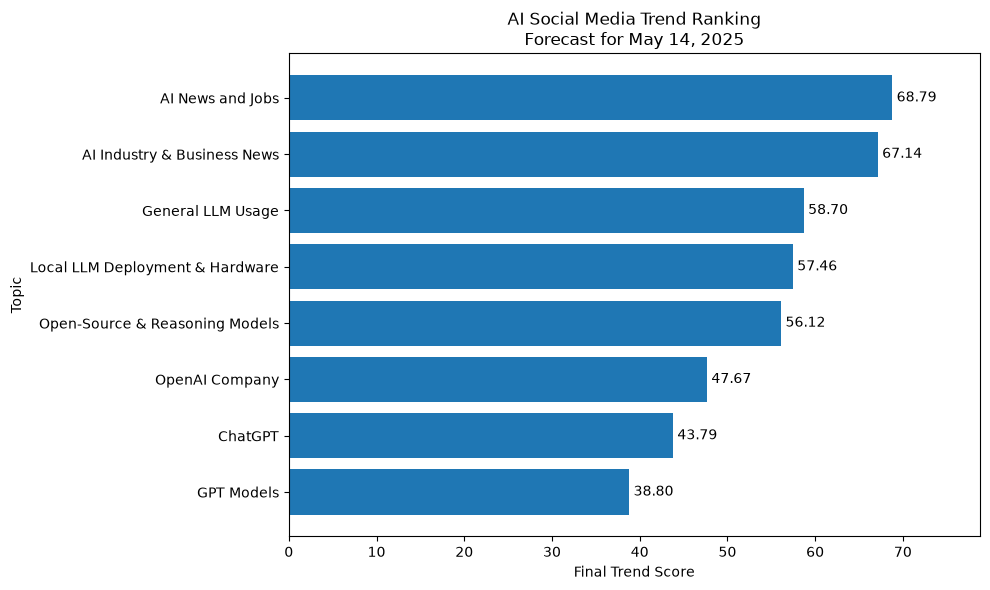

In [416]:
import matplotlib.pyplot as plt

# Sort from lowest to highest so highest appears at top
plot_data = final_ranking.sort_values(
    "final_trend_score",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data["topic_name"],
    plot_data["final_trend_score"]
)

plt.xlabel("Final Trend Score")
plt.ylabel("Topic")

plt.title(
    "AI Social Media Trend Ranking\n"
    "Forecast for May 14, 2025"
)

# Add score labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center"
    )

plt.xlim(
    0,
    final_ranking["final_trend_score"].max() + 10
)

plt.tight_layout()
plt.show()

In [417]:
import pandas as pd
import matplotlib.pyplot as plt

# Copy daily topic data
history = topic_daily.copy()

# Make sure date is datetime
history["date"] = pd.to_datetime(history["date"])

# Keep May 1 to May 14
history = history[
    (history["date"] >= "2025-05-01") &
    (history["date"] <= "2025-05-14")
]

# Create one column per topic
history_pivot = history.pivot(
    index="date",
    columns="topic_name",
    values="post_count"
).fillna(0)

print(history_pivot.head())

topic_name  AI Industry & Business News  AI News and Jobs  ChatGPT  \
date                                                                 
2025-05-01                           10                35       13   
2025-05-02                           12                34        8   
2025-05-03                           12                26       12   
2025-05-04                            9                24       10   
2025-05-05                           17                24        9   

topic_name  GPT Models  General LLM Usage  Local LLM Deployment & Hardware  \
date                                                                         
2025-05-01          13                 31                               38   
2025-05-02           5                 28                               31   
2025-05-03           9                 43                               25   
2025-05-04           8                 37                               12   
2025-05-05           8                 36

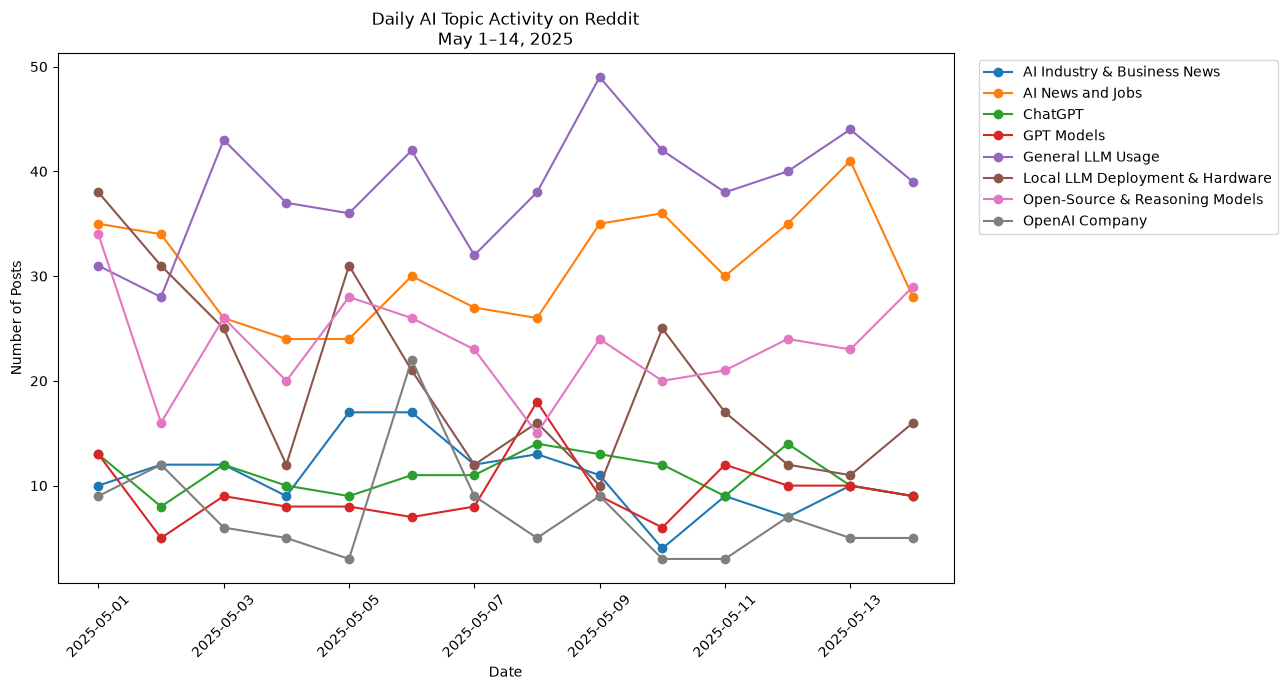

In [418]:
plt.figure(figsize=(13, 7))

for topic in history_pivot.columns:

    plt.plot(
        history_pivot.index,
        history_pivot[topic],
        marker="o",
        label=topic
    )

plt.title(
    "Daily AI Topic Activity on Reddit\n"
    "May 1–14, 2025"
)

plt.xlabel("Date")
plt.ylabel("Number of Posts")

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [419]:
print(
    history_pivot.max()
    .sort_values(ascending=False)
)

topic_name
General LLM Usage                  49
AI News and Jobs                   41
Local LLM Deployment & Hardware    38
Open-Source & Reasoning Models     34
OpenAI Company                     22
GPT Models                         18
AI Industry & Business News        17
ChatGPT                            14
dtype: int64


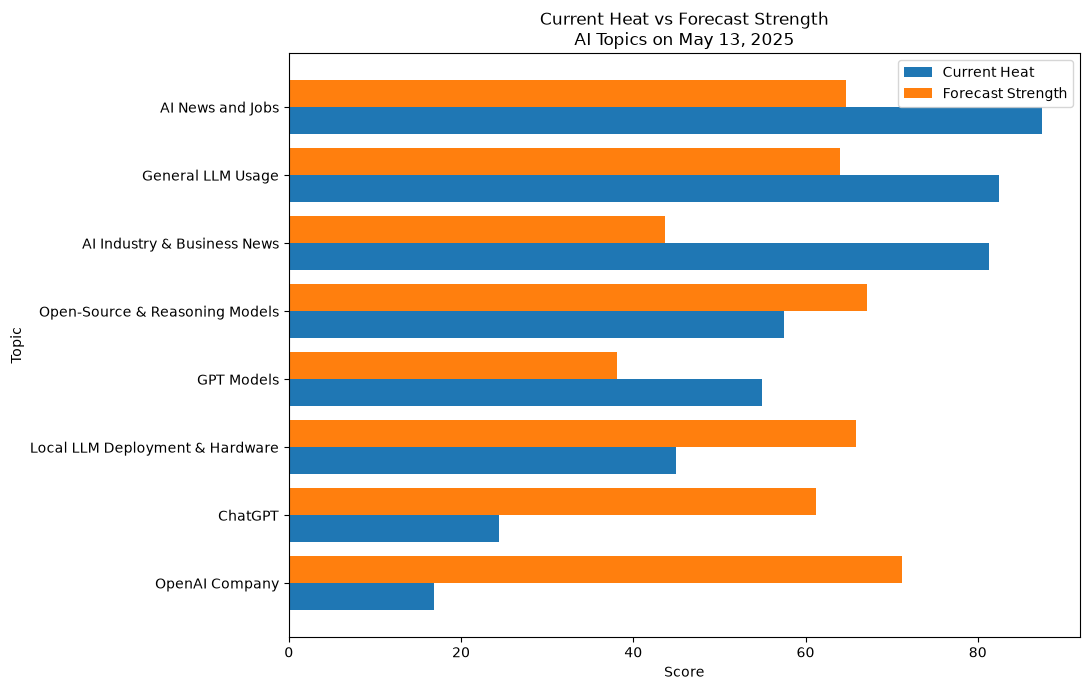

In [420]:
import matplotlib.pyplot as plt

comparison_data = final_ranking[
    [
        "topic_name",
        "current_heat_score",
        "forecast_strength_score"
    ]
].copy()

comparison_data = comparison_data.sort_values(
    "current_heat_score",
    ascending=True
)

y_positions = range(len(comparison_data))

plt.figure(figsize=(11, 7))

plt.barh(
    [y - 0.2 for y in y_positions],
    comparison_data["current_heat_score"],
    height=0.4,
    label="Current Heat"
)

plt.barh(
    [y + 0.2 for y in y_positions],
    comparison_data["forecast_strength_score"],
    height=0.4,
    label="Forecast Strength"
)

plt.yticks(
    list(y_positions),
    comparison_data["topic_name"]
)

plt.xlabel("Score")
plt.ylabel("Topic")

plt.title(
    "Current Heat vs Forecast Strength\n"
    "AI Topics on May 13, 2025"
)

plt.legend()

plt.tight_layout()
plt.show()

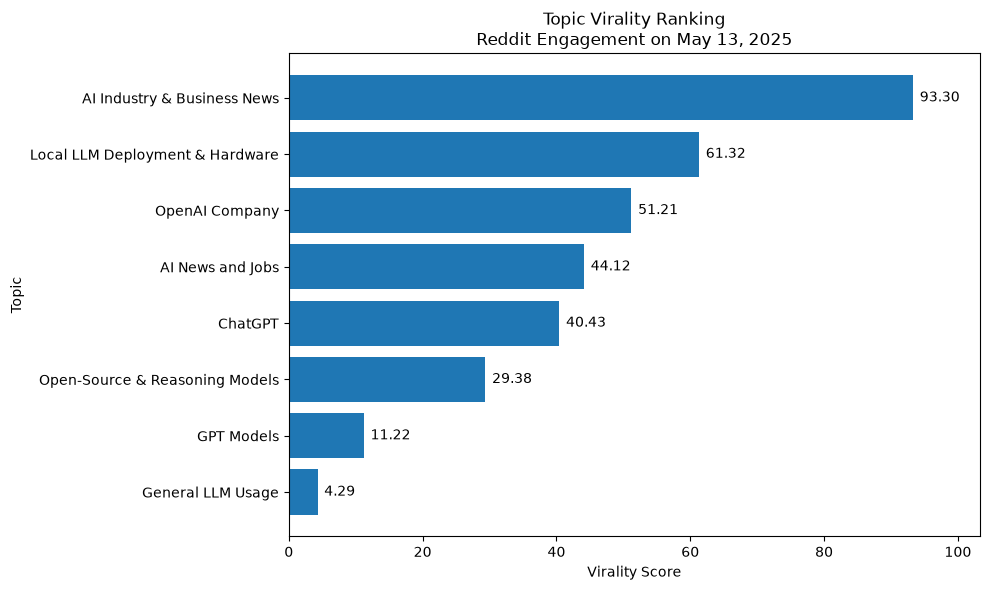

In [421]:
import matplotlib.pyplot as plt

virality_plot = final_ranking[
    [
        "topic_name",
        "virality_score"
    ]
].copy()

virality_plot = virality_plot.sort_values(
    "virality_score",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    virality_plot["topic_name"],
    virality_plot["virality_score"]
)

plt.xlabel("Virality Score")
plt.ylabel("Topic")

plt.title(
    "Topic Virality Ranking\n"
    "Reddit Engagement on May 13, 2025"
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center"
    )

plt.xlim(
    0,
    virality_plot["virality_score"].max() + 10
)

plt.tight_layout()
plt.show()

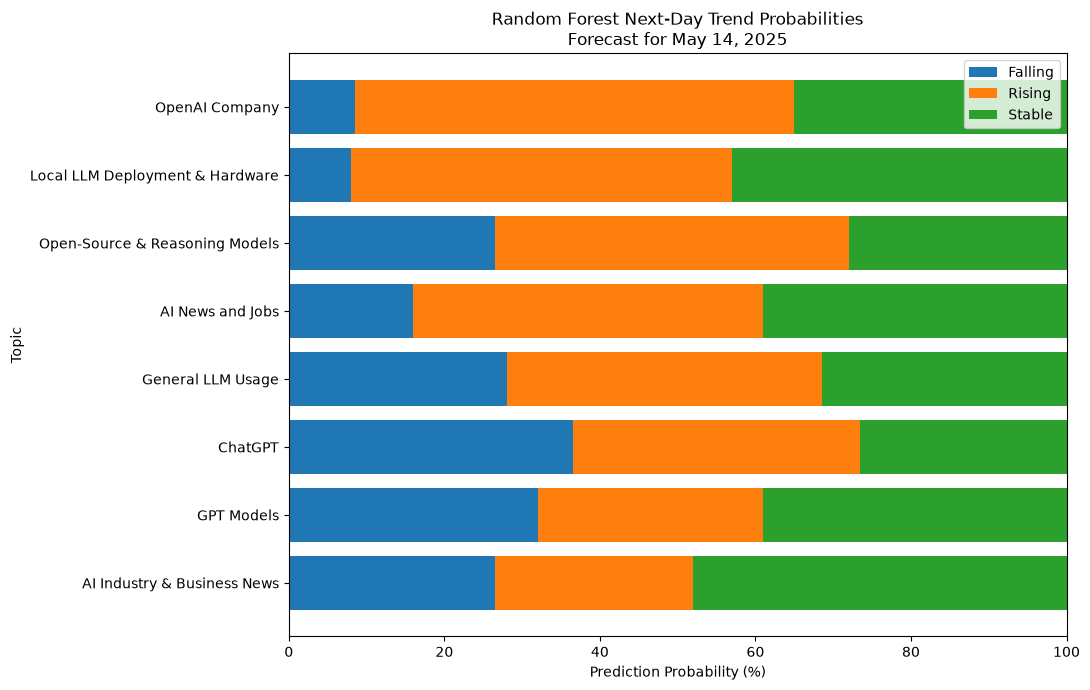

In [422]:
import matplotlib.pyplot as plt

prob_plot = trend_intelligence[
    [
        "topic_name",
        "Falling_probability",
        "Rising_probability",
        "Stable_probability"
    ]
].copy()

# Convert probability from 0–1 to percentage
prob_plot["Falling_probability"] *= 100
prob_plot["Rising_probability"] *= 100
prob_plot["Stable_probability"] *= 100

# Sort for cleaner display
prob_plot = prob_plot.sort_values(
    "Rising_probability",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    prob_plot["topic_name"],
    prob_plot["Falling_probability"],
    label="Falling"
)

plt.barh(
    prob_plot["topic_name"],
    prob_plot["Rising_probability"],
    left=prob_plot["Falling_probability"],
    label="Rising"
)

plt.barh(
    prob_plot["topic_name"],
    prob_plot["Stable_probability"],
    left=(
        prob_plot["Falling_probability"]
        + prob_plot["Rising_probability"]
    ),
    label="Stable"
)

plt.xlabel("Prediction Probability (%)")
plt.ylabel("Topic")

plt.title(
    "Random Forest Next-Day Trend Probabilities\n"
    "Forecast for May 14, 2025"
)

plt.xlim(0, 100)

plt.legend()

plt.tight_layout()
plt.show()

In [423]:
print(
    trend_intelligence[
        [
            "topic_name",
            "predicted_next_day_trend",
            "Falling_probability",
            "Rising_probability",
            "Stable_probability",
            "prediction_margin_percent"
        ]
    ].to_string(index=False)
)

                     topic_name predicted_next_day_trend  Falling_probability  Rising_probability  Stable_probability  prediction_margin_percent
              General LLM Usage                   Rising                0.280               0.405               0.315                        9.0
               AI News and Jobs                   Rising                0.160               0.450               0.390                        6.0
                        ChatGPT                   Rising                0.365               0.370               0.265                        0.5
                     GPT Models                   Stable                0.320               0.290               0.390                        7.0
                 OpenAI Company                   Rising                0.085               0.565               0.350                       21.5
 Open-Source & Reasoning Models                   Rising                0.265               0.455               0.280             

In [424]:
from pathlib import Path

project_dir = Path.cwd().parent
print("Project directory:", project_dir)

processed_dir = project_dir / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

print("Processed directory:", processed_dir)

Project directory: c:\Users\praharshaanugu\MLprojects\social-media-trend-analyser
Processed directory: c:\Users\praharshaanugu\MLprojects\social-media-trend-analyser\data\processed


In [425]:
final_ranking.to_csv(
    processed_dir / "final_ranking.csv",
    index=False
)

trend_intelligence.to_csv(
    processed_dir / "trend_intelligence.csv",
    index=False
)

topic_daily.to_csv(
    processed_dir / "topic_daily.csv",
    index=False
)

df_posts.to_csv(
    processed_dir / "posts.csv",
    index=False
)

In [426]:
topic_daily["topic_name"] = (
    topic_daily["topic"].map(topic_names)
)

saving

In [428]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

for name, obj in globals().copy().items():

    if isinstance(
        obj,
        (
            TfidfVectorizer,
            KMeans,
            RandomForestClassifier,
            LogisticRegression,
            DecisionTreeClassifier
        )
    ):
        print(
            name,
            "→",
            type(obj).__name__
        )

vectorizer → TfidfVectorizer
vectorizer_topic → TfidfVectorizer
rf_model → RandomForestClassifier
rf_engineered → RandomForestClassifier
_319 → RandomForestClassifier
dt_model → DecisionTreeClassifier
model → LogisticRegression
final_model → RandomForestClassifier
_357 → RandomForestClassifier
interpret_vectorizer → TfidfVectorizer


In [429]:
print("X shape:", X.shape)

print("\nFeatures used by final forecasting model:")

for column in X.columns:
    print(column)

X shape: (103, 16)

Features used by final forecasting model:
post_count
previous_post_count
growth
growth_rate
day_of_week
trend_Falling
trend_Rising
trend_Stable
topic_0
topic_1
topic_2
topic_3
topic_4
topic_5
topic_6
topic_7


In [430]:
from sklearn.cluster import KMeans, MiniBatchKMeans

for name, obj in globals().copy().items():

    if isinstance(
        obj,
        (
            KMeans,
            MiniBatchKMeans
        )
    ):
        print(
            name,
            "→",
            type(obj).__name__,
            "clusters:",
            obj.n_clusters
        )

In [431]:
for name, obj in globals().copy().items():

    if (
        hasattr(obj, "cluster_centers_")
        and
        hasattr(obj, "predict")
    ):

        print(
            name,
            "→",
            type(obj).__name__,
            "centers shape:",
            obj.cluster_centers_.shape
        )

In [432]:
for name in [
    "vectorizer",
    "vectorizer_topic",
    "interpret_vectorizer"
]:

    if name in globals():

        obj = globals()[name]

        print("\n", name)

        print(
            "Vocabulary size:",
            len(obj.get_feature_names_out())
        )

        print(
            "max_features:",
            obj.max_features
        )

        print(
            "ngram_range:",
            obj.ngram_range
        )


 vectorizer
Vocabulary size: 5000
max_features: 5000
ngram_range: (1, 2)

 vectorizer_topic
Vocabulary size: 5000
max_features: 5000
ngram_range: (1, 2)

 interpret_vectorizer
Vocabulary size: 3000
max_features: 3000
ngram_range: (1, 2)


In [433]:
import numpy as np

print(
    "Same vocabulary:",
    vectorizer.vocabulary_ == vectorizer_topic.vocabulary_
)

print(
    "Same IDF values:",
    np.allclose(
        vectorizer.idf_,
        vectorizer_topic.idf_
    )
)

print(
    "Same parameters:",
    vectorizer.get_params() == vectorizer_topic.get_params()
)

Same vocabulary: False
Same IDF values: False
Same parameters: False


In [434]:
from sklearn.cluster import KMeans, MiniBatchKMeans

for name, obj in globals().copy().items():

    if isinstance(obj, (KMeans, MiniBatchKMeans)):

        print(
            name,
            "→",
            type(obj).__name__,
            "clusters:",
            obj.n_clusters,
            "centers:",
            obj.cluster_centers_.shape
        )

In [435]:
for name, obj in globals().copy().items():

    if (
        hasattr(obj, "cluster_centers_")
        and hasattr(obj, "predict")
    ):

        print(
            name,
            "→",
            type(obj).__name__,
            obj.cluster_centers_.shape
        )

In [436]:
for i, cell in enumerate(_ih):

    if "KMeans" in cell or "kmeans" in cell:

        print("\n" + "=" * 70)
        print("CELL:", i)
        print("=" * 70)

        print(cell)


CELL: 428
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

for name, obj in globals().copy().items():

    if isinstance(
        obj,
        (
            TfidfVectorizer,
            KMeans,
            RandomForestClassifier,
            LogisticRegression,
            DecisionTreeClassifier
        )
    ):
        print(
            name,
            "→",
            type(obj).__name__
        )

CELL: 430
from sklearn.cluster import KMeans, MiniBatchKMeans

for name, obj in globals().copy().items():

    if isinstance(
        obj,
        (
            KMeans,
            MiniBatchKMeans
        )
    ):
        print(
            name,
            "→",
            type(obj).__name__,
            "clusters:",
            obj.n_clusters
        )

CELL: 434
from sklearn.cluster impo

In [437]:
for i, cell in enumerate(_ih):

    if "fit_predict" in cell:

        print("\n" + "=" * 70)
        print("CELL:", i)
        print("=" * 70)

        print(cell)


CELL: 437
for i, cell in enumerate(_ih):

    if "fit_predict" in cell:

        print("\n" + "=" * 70)
        print("CELL:", i)
        print("=" * 70)

        print(cell)


In [438]:
for i, cell in enumerate(_ih):

    if "vectorizer_topic" in cell:

        print("\n" + "=" * 70)
        print("CELL:", i)
        print("=" * 70)

        print(cell)


CELL: 62
vectorizer_topic = TfidfVectorizer(
    stop_words=list(custom_stopwords),
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85,
    max_features=5000
)

X_topic = vectorizer_topic.fit_transform(topic_text)

print("New TF-IDF shape:", X_topic.shape)

CELL: 63
feature_names_topic = vectorizer_topic.get_feature_names_out()

mean_tfidf_topic = np.asarray(
    X_topic.mean(axis=0)
).ravel()

top_indices = mean_tfidf_topic.argsort()[::-1][:50]

top_terms_topic = [
    (feature_names_topic[i], mean_tfidf_topic[i])
    for i in top_indices
]

top_terms_topic[:30]

CELL: 214
vectorizer_topic = TfidfVectorizer(
    stop_words=list(custom_stopwords),
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85,
    max_features=5000
)

X_topic = vectorizer_topic.fit_transform(topic_text)

print("New TF-IDF shape:", X_topic.shape)

CELL: 215
feature_names_topic = vectorizer_topic.get_feature_names_out()

mean_tfidf_topic = np.asarray(
    X_topic.mean(axis=0)
).ravel()

top_indices = mean_tfi

In [439]:
for i, cell in enumerate(_ih):

    if "vectorizer =" in cell:

        print("\n" + "=" * 70)
        print("CELL:", i)
        print("=" * 70)

        print(cell)


CELL: 50
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    min_df=5
)

X = vectorizer.fit_transform(
    df_posts["clean_text"].astype(str)
)

phrases = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

phrase_counts = sorted(
    zip(phrases, counts),
    key=lambda x: x[1],
    reverse=True
)

phrase_counts[:30]

CELL: 52
for subreddit in df_posts["subreddit"].unique():

    subset = df_posts[
        df_posts["subreddit"] == subreddit
    ]

    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=(2, 2),
        min_df=3
    )

    X = vectorizer.fit_transform(
        subset["clean_text"].astype(str)
    )

    phrases = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1

    phrase_counts = sorted(
        zip(phrases, counts),
        key=lambda x: x[1],
        reverse=True
    )

    print("\n" + "=" * 50)
    print(subreddit)
   

In [440]:
search_terms = [
    "n_clusters",
    "fit_predict",
    "X_topic",
    'df_posts["topic"]',
    "cluster_centers_",
    "labels_"
]

for i, cell in enumerate(_ih[:400]):

    if any(
        term.lower() in cell.lower()
        for term in search_terms
    ):

        print("\n" + "=" * 70)
        print("CELL:", i)
        print("=" * 70)

        # Limit output so VS Code does not truncate everything
        print(cell[:1500])


CELL: 62
vectorizer_topic = TfidfVectorizer(
    stop_words=list(custom_stopwords),
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85,
    max_features=5000
)

X_topic = vectorizer_topic.fit_transform(topic_text)

print("New TF-IDF shape:", X_topic.shape)

CELL: 63
feature_names_topic = vectorizer_topic.get_feature_names_out()

mean_tfidf_topic = np.asarray(
    X_topic.mean(axis=0)
).ravel()

top_indices = mean_tfidf_topic.argsort()[::-1][:50]

top_terms_topic = [
    (feature_names_topic[i], mean_tfidf_topic[i])
    for i in top_indices
]

top_terms_topic[:30]

CELL: 69
# Find the topic with the highest score for each post
dominant_topic = W.argmax(axis=1)

# Add the topic number to our dataframe
df_posts["topic"] = dominant_topic

# Display the first few posts with their topics
df_posts[["subreddit", "clean_text", "topic"]].head(10)

CELL: 70
topic_counts = df_posts["topic"].value_counts().sort_index()

print(topic_counts)

CELL: 71
topic_names = {
    0: "General LLM Usage",
 

In [441]:
kmeans = KMeans(
    n_clusters=8,
    random_state=42
)

df_posts["topic"] = kmeans.fit_predict(X_topic)

In [442]:
labels = KMeans(
    n_clusters=8,
    random_state=42
).fit_predict(X_topic)

In [443]:
for i, cell in enumerate(_ih):

    if 55 <= i <= 100:

        lines = cell.splitlines()

        matching_lines = [
            line.strip()
            for line in lines
            if any(
                word in line.lower()
                for word in [
                    "kmeans",
                    "n_clusters",
                    "fit_predict",
                    "x_topic",
                    '["topic"]'
                ]
            )
        ]

        if matching_lines:

            print(f"\nCELL {i}")

            for line in matching_lines:
                print(line)


CELL 62
X_topic = vectorizer_topic.fit_transform(topic_text)
print("New TF-IDF shape:", X_topic.shape)

CELL 63
X_topic.mean(axis=0)

CELL 69
df_posts["topic"] = dominant_topic

CELL 70
topic_counts = df_posts["topic"].value_counts().sort_index()

CELL 71
df_posts["topic_name"] = df_posts["topic"].map(topic_names)

CELL 73
for topic in sorted(df_posts["topic"].unique()):
sample_posts = df_posts[df_posts["topic"] == topic]["clean_text"].head(3)

CELL 75
for topic in sorted(df_posts["topic"].unique()):
sample_posts = df_posts[df_posts["topic"] == topic]["clean_text"].head(5)


In [444]:
for i, cell in enumerate(_ih):

    if "KMeans(" in cell:

        print("CELL:", i)

        for line in cell.splitlines():
            print(line)

CELL: 441
kmeans = KMeans(
    n_clusters=8,
    random_state=42
)

df_posts["topic"] = kmeans.fit_predict(X_topic)
CELL: 442
labels = KMeans(
    n_clusters=8,
    random_state=42
).fit_predict(X_topic)
CELL: 444
for i, cell in enumerate(_ih):

    if "KMeans(" in cell:

        print("CELL:", i)

        for line in cell.splitlines():
            print(line)


In [445]:
for i, cell in enumerate(_ih):

    if "fit_predict" in cell:

        print("CELL:", i)

        for line in cell.splitlines():
            print(line)

CELL: 437
for i, cell in enumerate(_ih):

    if "fit_predict" in cell:

        print("\n" + "=" * 70)
        print("CELL:", i)
        print("=" * 70)

        print(cell)
CELL: 440
search_terms = [
    "n_clusters",
    "fit_predict",
    "X_topic",
    'df_posts["topic"]',
    "cluster_centers_",
    "labels_"
]

for i, cell in enumerate(_ih[:400]):

    if any(
        term.lower() in cell.lower()
        for term in search_terms
    ):

        print("\n" + "=" * 70)
        print("CELL:", i)
        print("=" * 70)

        # Limit output so VS Code does not truncate everything
        print(cell[:1500])
CELL: 441
kmeans = KMeans(
    n_clusters=8,
    random_state=42
)

df_posts["topic"] = kmeans.fit_predict(X_topic)
CELL: 442
labels = KMeans(
    n_clusters=8,
    random_state=42
).fit_predict(X_topic)
CELL: 443
for i, cell in enumerate(_ih):

    if 55 <= i <= 100:

        lines = cell.splitlines()

        matching_lines = [
            line.strip()
            for line in

In [447]:
for i in range(64, 70):

    print("\n" + "=" * 60)
    print("CELL", i)
    print("=" * 60)

    print(_ih[i])


CELL 64
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_tfidf = vectorizer.fit_transform(df_posts["clean_text"])

print("TF-IDF shape:", X_tfidf.shape)
print("Number of features:", len(vectorizer.get_feature_names_out()))

CELL 65
feature_names = vectorizer.get_feature_names_out()

tfidf_scores = X_tfidf.mean(axis=0).A1

top_terms = sorted(
    zip(feature_names, tfidf_scores),
    key=lambda x: x[1],
    reverse=True
)[:50]

top_terms

CELL 66
from sklearn.decomposition import NMF

CELL 67
n_topics = 8

nmf_model = NMF(
    n_components=n_topics,
    random_state=42,
    init="nndsvda",
    max_iter=500
)

W = nmf_model.fit_transform(X_tfidf)
H = nmf_model.components_

print("W shape:", W.shape)
print("H shape:", H.shape)

CELL 68
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()

In [448]:
keywords = [
    "NMF",
    "nmf",
    "fit_transform",
    "components_",
    "dominant_topic",
    "argmax",
    "W",
    "H"
]

for i in range(64, 70):

    cell = _ih[i]

    matching_lines = [
        line.strip()
        for line in cell.splitlines()
        if any(
            keyword.lower() in line.lower()
            for keyword in keywords
        )
    ]

    if matching_lines:

        print(f"\nCELL {i}")

        for line in matching_lines:
            print(line)


CELL 64
stop_words="english",
X_tfidf = vectorizer.fit_transform(df_posts["clean_text"])
print("TF-IDF shape:", X_tfidf.shape)

CELL 66
from sklearn.decomposition import NMF

CELL 67
nmf_model = NMF(
W = nmf_model.fit_transform(X_tfidf)
H = nmf_model.components_
print("W shape:", W.shape)
print("H shape:", H.shape)

CELL 68
for topic_idx, topic in enumerate(H):

CELL 69
# Find the topic with the highest score for each post
dominant_topic = W.argmax(axis=1)
# Add the topic number to our dataframe
df_posts["topic"] = dominant_topic
# Display the first few posts with their topics
df_posts[["subreddit", "clean_text", "topic"]].head(10)


In [449]:
print("NMF exists:", "nmf_model" in globals())
print("NMF type:", type(nmf_model).__name__)

print("NMF components shape:")
print(nmf_model.components_.shape)

print("\nVectorizer features:")
print(len(vectorizer.get_feature_names_out()))

NMF exists: True
NMF type: NMF
NMF components shape:
(8, 5000)

Vectorizer features:
5000


In [450]:
X_verify = vectorizer.transform(
    df_posts["clean_text"].fillna("")
)

W_verify = nmf_model.transform(X_verify)

nmf_topics = W_verify.argmax(axis=1)

print("Number of predictions:", len(nmf_topics))
print("Unique topics:", sorted(set(nmf_topics)))

Number of predictions: 2158
Unique topics: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [451]:
saved_posts = pd.read_csv(
    processed_dir / "posts.csv"
)

print(saved_posts.shape)

(2158, 12)


In [452]:
comparison = (
    nmf_topics
    == saved_posts["topic"].to_numpy()
)

print(
    "NMF topic match:",
    comparison.mean() * 100,
    "%"
)

NMF topic match: 100.0 %


In [453]:
df_posts["topic"] = nmf_topics

In [454]:
topic_names = {
    0: "General LLM Usage",
    1: "AI News and Jobs",
    2: "ChatGPT",
    3: "GPT Models",
    4: "OpenAI Company",
    5: "Open-Source & Reasoning Models",
    6: "Local LLM Deployment & Hardware",
    7: "AI Industry & Business News"
}

df_posts["topic_name"] = (
    df_posts["topic"].map(topic_names)
)

In [455]:
from pathlib import Path

models_dir = project_dir / "models"

models_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(models_dir)

c:\Users\praharshaanugu\MLprojects\social-media-trend-analyser\models


In [456]:
import joblib

joblib.dump(
    vectorizer,
    models_dir / "topic_vectorizer.joblib"
)

joblib.dump(
    nmf_model,
    models_dir / "nmf_topic_model.joblib"
)

joblib.dump(
    final_model,
    models_dir / "trend_forecaster.joblib"
)

print("Models saved successfully.")

Models saved successfully.


In [457]:
import json

feature_columns = [
    "post_count",
    "previous_post_count",
    "growth",
    "growth_rate",
    "day_of_week",
    "trend_Falling",
    "trend_Rising",
    "trend_Stable",
    "topic_0",
    "topic_1",
    "topic_2",
    "topic_3",
    "topic_4",
    "topic_5",
    "topic_6",
    "topic_7"
]

with open(
    models_dir / "feature_columns.json",
    "w"
) as f:

    json.dump(
        feature_columns,
        f,
        indent=4
    )

In [458]:
topic_names = {
    0: "General LLM Usage",
    1: "AI News and Jobs",
    2: "ChatGPT",
    3: "GPT Models",
    4: "OpenAI Company",
    5: "Open-Source & Reasoning Models",
    6: "Local LLM Deployment & Hardware",
    7: "AI Industry & Business News"
}

with open(
    models_dir / "topic_names.json",
    "w"
) as f:

    json.dump(
        topic_names,
        f,
        indent=4
    )

In [459]:
project_config = {

    "trend_thresholds": {
        "rising": 0.20,
        "falling": -0.20
    },

    "current_heat_weights": {
        "growth": 0.70,
        "volume": 0.30
    },

    "forecast_strength_weights": {
        "direction": 0.50,
        "prediction_probability": 0.30,
        "prediction_margin": 0.20
    },

    "trend_intelligence_weights": {
        "current_heat": 0.45,
        "forecast_strength": 0.55
    },

    "virality_weights": {
        "average_score": 0.40,
        "median_score": 0.35,
        "maximum_score": 0.25
    },

    "final_score_weights": {
        "trend_intelligence": 0.80,
        "virality": 0.20
    }
}

with open(
    models_dir / "project_config.json",
    "w"
) as f:

    json.dump(
        project_config,
        f,
        indent=4
    )

In [460]:
for file in models_dir.iterdir():
    print(file.name)

feature_columns.json
nmf_topic_model.joblib
project_config.json
topic_names.json
topic_vectorizer.joblib
trend_forecaster.joblib


In [461]:
import joblib
import json

# Reload saved models
loaded_vectorizer = joblib.load(
    models_dir / "topic_vectorizer.joblib"
)

loaded_nmf = joblib.load(
    models_dir / "nmf_topic_model.joblib"
)

loaded_forecaster = joblib.load(
    models_dir / "trend_forecaster.joblib"
)

# Reload feature columns
with open(
    models_dir / "feature_columns.json",
    "r"
) as f:
    loaded_feature_columns = json.load(f)

# Reload topic names
with open(
    models_dir / "topic_names.json",
    "r"
) as f:
    loaded_topic_names = json.load(f)

# JSON converts integer keys into strings
loaded_topic_names = {
    int(key): value
    for key, value in loaded_topic_names.items()
}

# Reload project configuration
with open(
    models_dir / "project_config.json",
    "r"
) as f:
    loaded_config = json.load(f)

print("Everything loaded successfully.")

Everything loaded successfully.


In [462]:
X_loaded_topic = loaded_vectorizer.transform(
    df_posts["clean_text"].fillna("")
)

W_loaded = loaded_nmf.transform(
    X_loaded_topic
)

loaded_topics = W_loaded.argmax(axis=1)

In [463]:
topic_match = (
    loaded_topics == nmf_topics
).mean()

print(
    "Reloaded topic match:",
    topic_match * 100,
    "%"
)

Reloaded topic match: 100.0 %


In [464]:
for topic_id in range(8):

    print(
        topic_id,
        "→",
        loaded_topic_names[topic_id]
    )

0 → General LLM Usage
1 → AI News and Jobs
2 → ChatGPT
3 → GPT Models
4 → OpenAI Company
5 → Open-Source & Reasoning Models
6 → Local LLM Deployment & Hardware
7 → AI Industry & Business News


In [465]:
print(
    "Saved feature count:",
    len(loaded_feature_columns)
)

print("\nSaved feature order:")

for column in loaded_feature_columns:
    print(column)

Saved feature count: 16

Saved feature order:
post_count
previous_post_count
growth
growth_rate
day_of_week
trend_Falling
trend_Rising
trend_Stable
topic_0
topic_1
topic_2
topic_3
topic_4
topic_5
topic_6
topic_7


In [466]:
print(
    "\nFeature order matches:",
    loaded_feature_columns
    == X.columns.tolist()
)


Feature order matches: True


In [467]:
reloaded_predictions = loaded_forecaster.predict(
    X_forecast[loaded_feature_columns]
)

print(
    "Reloaded predictions:"
)

print(reloaded_predictions)

Reloaded predictions:
['Rising' 'Rising' 'Rising' 'Stable' 'Rising' 'Rising' 'Rising' 'Stable']


In [468]:
import numpy as np

print(
    "Forecast predictions identical:",
    np.array_equal(
        reloaded_predictions,
        forecast_predictions
    )
)

Forecast predictions identical: True


In [469]:
reloaded_probabilities = (
    loaded_forecaster.predict_proba(
        X_forecast[loaded_feature_columns]
    )
)

print(
    "Probability outputs identical:",
    np.allclose(
        reloaded_probabilities,
        forecast_probabilities
    )
)

Probability outputs identical: True


In [470]:
for i, cell in enumerate(_ih):

    if (
        'clean_text' in cell
        and i < 100
    ):

        print("\n" + "=" * 60)
        print("CELL", i)
        print("=" * 60)

        print(cell[:1800])


CELL 38
import re

def clean_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Remove Reddit/Markdown links
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)

    # Remove markdown formatting
    text = re.sub(r'[*_~`]', ' ', text)

    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

CELL 39
df_text["clean_text"] = df_text["text"].apply(clean_text)

CELL 40
df_text[["text", "clean_text"]].sample(
    15,
    random_state=42
)

CELL 42
df_posts = df_posts[
    df_posts["clean_text"].str.len() >= 30
].copy()

print("Posts after length filtering:", len(df_posts))

CELL 50
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    min_df=5
)

X = vectorizer.fit_transform(
    df_posts["clean_text"].astype(str)
)

phrases = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

phrase

In [473]:
import re

def clean_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' ',
        text
    )

    # Remove Reddit/Markdown links
    text = re.sub(
        r'\[([^\]]+)\]\([^)]+\)',
        r'\1',
        text
    )

    # Remove markdown formatting
    text = re.sub(
        r'[\*_\~`]',
        ' ',
        text
    )

    # Remove excessive whitespace
    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip()

In [474]:
import numpy as np

def predict_topic(text):

    # 1. Clean the new text
    cleaned = clean_text(text)

    # 2. Convert text into the SAME TF-IDF feature space
    X_new = loaded_vectorizer.transform(
        [cleaned]
    )

    # 3. Get NMF topic weights
    topic_weights = loaded_nmf.transform(
        X_new
    )

    # 4. Topic with highest weight
    topic_id = int(
        np.argmax(topic_weights[0])
    )

    # 5. Convert topic ID into readable name
    topic_name = loaded_topic_names[
        topic_id
    ]

    return {
        "cleaned_text": cleaned,
        "topic_id": topic_id,
        "topic_name": topic_name,
        "topic_strength": float(
            topic_weights[0][topic_id]
        )
    }

In [475]:
result = predict_topic(
    "Qwen released a new open-source reasoning model "
    "that can run locally on consumer hardware."
)

print(result)

{'cleaned_text': 'Qwen released a new open-source reasoning model that can run locally on consumer hardware.', 'topic_id': 5, 'topic_name': 'Open-Source & Reasoning Models', 'topic_strength': 0.13518271412309368}


In [476]:
def classify_posts(new_posts):

    df = new_posts.copy()

    # Clean all text
    df["clean_text"] = (
        df["text"]
        .fillna("")
        .apply(clean_text)
    )

    # Convert ALL posts into TF-IDF at once
    X_new = loaded_vectorizer.transform(
        df["clean_text"]
    )

    # Get NMF topic weights
    W_new = loaded_nmf.transform(
        X_new
    )

    # Highest-weight topic for every post
    df["topic"] = W_new.argmax(axis=1)

    # Topic strength
    df["topic_strength"] = W_new.max(axis=1)

    # Human-readable topic names
    df["topic_name"] = (
        df["topic"]
        .map(loaded_topic_names)
    )

    return df

In [477]:
new_posts = pd.DataFrame({
    "text": [
        "Qwen released a new open-source reasoning model.",
        
        "I am running Llama using Ollama on my RTX GPU "
        "and need more VRAM.",
        
        "OpenAI reportedly acquired a new AI startup.",
        
        "ChatGPT introduced a new feature for users.",
        
        "Microsoft and Google continue investing heavily "
        "in artificial intelligence."
    ]
})

In [478]:
classified_posts = classify_posts(
    new_posts
)

print(
    classified_posts[
        [
            "text",
            "topic",
            "topic_name",
            "topic_strength"
        ]
    ].to_string(index=False)
)

                                                                       text  topic                      topic_name  topic_strength
                           Qwen released a new open-source reasoning model.      5  Open-Source & Reasoning Models        0.190988
          I am running Llama using Ollama on my RTX GPU and need more VRAM.      6 Local LLM Deployment & Hardware        0.108775
                               OpenAI reportedly acquired a new AI startup.      7     AI Industry & Business News        0.114178
                                ChatGPT introduced a new feature for users.      2                         ChatGPT        0.155836
Microsoft and Google continue investing heavily in artificial intelligence.      7     AI Industry & Business News        0.037510


In [479]:
def aggregate_daily_topics(classified_df):

    df = classified_df.copy()

    # Convert timestamp
    df["created_at"] = pd.to_datetime(
        df["created_at"],
        errors="coerce"
    )

    # Extract calendar date
    df["date"] = df["created_at"].dt.date

    # Count posts for every topic each day
    daily = (
        df.groupby(
            ["date", "topic", "topic_name"]
        )
        .agg(
            post_count=("text", "count")
        )
        .reset_index()
    )

    return daily

In [480]:
new_posts = pd.DataFrame({

    "created_at": [
        "2026-09-10 09:00",
        "2026-09-10 10:30",
        "2026-09-10 15:00",

        "2026-09-11 08:00",
        "2026-09-11 12:30",
        "2026-09-11 17:00",

        "2026-09-12 09:30",
        "2026-09-12 13:00",
        "2026-09-12 20:00"
    ],

    "text": [
        "Qwen released a new open-source reasoning model.",
        "Running Llama locally with Ollama and an RTX GPU.",
        "ChatGPT introduced a new feature.",

        "New open-source reasoning model released today.",
        "Need more VRAM to run Qwen locally.",
        "OpenAI acquired another AI startup.",

        "Qwen reasoning benchmarks look very impressive.",
        "Ollama performance improved on consumer GPUs.",
        "Microsoft announces another major AI investment."
    ],

    "score": [
        50, 30, 100,
        75, 40, 120,
        90, 55, 150
    ]
})

In [481]:
classified_new_posts = classify_posts(
    new_posts
)

In [482]:
new_topic_daily = aggregate_daily_topics(
    classified_new_posts
)

print(
    new_topic_daily.to_string(
        index=False
    )
)

      date  topic                      topic_name  post_count
2026-09-10      2                         ChatGPT           1
2026-09-10      5  Open-Source & Reasoning Models           1
2026-09-10      6 Local LLM Deployment & Hardware           1
2026-09-11      5  Open-Source & Reasoning Models           1
2026-09-11      6 Local LLM Deployment & Hardware           1
2026-09-11      7     AI Industry & Business News           1
2026-09-12      1                AI News and Jobs           1
2026-09-12      5  Open-Source & Reasoning Models           1
2026-09-12      6 Local LLM Deployment & Hardware           1


In [483]:
import pandas as pd
import numpy as np

def complete_topic_grid(daily_df):

    df = daily_df.copy()

    # Make sure date is datetime
    df["date"] = pd.to_datetime(df["date"])

    # All dates between first and last date
    all_dates = pd.date_range(
        start=df["date"].min(),
        end=df["date"].max(),
        freq="D"
    )

    # We always have 8 topics
    all_topics = list(range(8))

    # Create every possible date-topic combination
    complete_index = pd.MultiIndex.from_product(
        [all_dates, all_topics],
        names=["date", "topic"]
    )

    complete = (
        df.set_index(["date", "topic"])
        .reindex(complete_index)
        .reset_index()
    )

    # Missing post counts mean zero posts
    complete["post_count"] = (
        complete["post_count"]
        .fillna(0)
        .astype(int)
    )

    # Restore topic names
    complete["topic_name"] = (
        complete["topic"]
        .map(loaded_topic_names)
    )

    return complete

In [484]:
complete_daily = complete_topic_grid(
    new_topic_daily
)

print(
    complete_daily.to_string(
        index=False
    )
)

      date  topic                      topic_name  post_count
2026-09-10      0               General LLM Usage           0
2026-09-10      1                AI News and Jobs           0
2026-09-10      2                         ChatGPT           1
2026-09-10      3                      GPT Models           0
2026-09-10      4                  OpenAI Company           0
2026-09-10      5  Open-Source & Reasoning Models           1
2026-09-10      6 Local LLM Deployment & Hardware           1
2026-09-10      7     AI Industry & Business News           0
2026-09-11      0               General LLM Usage           0
2026-09-11      1                AI News and Jobs           0
2026-09-11      2                         ChatGPT           0
2026-09-11      3                      GPT Models           0
2026-09-11      4                  OpenAI Company           0
2026-09-11      5  Open-Source & Reasoning Models           1
2026-09-11      6 Local LLM Deployment & Hardware           1
2026-09-

In [485]:
print("Rows:", len(complete_daily))
print("Dates:", complete_daily["date"].nunique())
print("Topics:", complete_daily["topic"].nunique())

Rows: 24
Dates: 3
Topics: 8


In [486]:
complete_daily = (
    complete_daily
    .sort_values(
        ["topic", "date"]
    )
    .reset_index(drop=True)
)

In [490]:
complete_daily["previous_post_count"] = (
    complete_daily
    .groupby("topic")["post_count"]
    .shift(1)
)

In [491]:
complete_daily["growth"] = (
    complete_daily["post_count"]
    -
    complete_daily["previous_post_count"]
)

In [492]:
complete_daily["growth"] = (
    complete_daily["post_count"]
    -
    complete_daily["previous_post_count"]
)

In [493]:
complete_daily["growth_rate"] = np.where(
    complete_daily["previous_post_count"] > 0,

    complete_daily["growth"]
    /
    complete_daily["previous_post_count"],

    np.nan
)

In [495]:
def assign_trend(row):

    current = row["post_count"]
    previous = row["previous_post_count"]
    rate = row["growth_rate"]

    # First observation for a topic
    if pd.isna(previous):
        return "Unknown"

    # No activity on either day
    if previous == 0 and current == 0:
        return "Stable"

    # Topic appears after having zero posts
    if previous == 0 and current > 0:
        return "Rising"

    # Normal percentage-based cases
    if rate >= 0.20:
        return "Rising"

    elif rate <= -0.20:
        return "Falling"

    else:
        return "Stable"

In [496]:
complete_daily["trend"] = (
    complete_daily.apply(
        assign_trend,
        axis=1
    )
)

In [497]:
print(
    complete_daily[
        [
            "date",
            "topic_name",
            "post_count",
            "previous_post_count",
            "growth",
            "growth_rate",
            "trend"
        ]
    ].to_string(index=False)
)

      date                      topic_name  post_count  previous_post_count  growth  growth_rate   trend
2026-09-10               General LLM Usage           0                  NaN     NaN          NaN Unknown
2026-09-11               General LLM Usage           0                  0.0     0.0          NaN  Stable
2026-09-12               General LLM Usage           0                  0.0     0.0          NaN  Stable
2026-09-10                AI News and Jobs           0                  NaN     NaN          NaN Unknown
2026-09-11                AI News and Jobs           0                  0.0     0.0          NaN  Stable
2026-09-12                AI News and Jobs           1                  0.0     1.0          NaN  Rising
2026-09-10                         ChatGPT           1                  NaN     NaN          NaN Unknown
2026-09-11                         ChatGPT           0                  1.0    -1.0         -1.0 Falling
2026-09-12                         ChatGPT           0 

In [498]:
def build_forecast_features(daily_df):

    df = daily_df.copy()

    # Make sure date is datetime
    df["date"] = pd.to_datetime(df["date"])

    # We forecast using the latest available date
    latest_date = df["date"].max()

    latest = df[
        df["date"] == latest_date
    ].copy()

    # The trained model needs a valid growth rate
    latest = latest[
        latest["growth_rate"].notna()
    ].copy()

    # Day of week:
    # Monday = 0, Tuesday = 1, ..., Sunday = 6
    latest["day_of_week"] = (
        latest["date"].dt.dayofweek
    )

    # -----------------------------------
    # Trend one-hot columns
    # -----------------------------------

    latest["trend_Falling"] = (
        latest["trend"] == "Falling"
    ).astype(int)

    latest["trend_Rising"] = (
        latest["trend"] == "Rising"
    ).astype(int)

    latest["trend_Stable"] = (
        latest["trend"] == "Stable"
    ).astype(int)

    # -----------------------------------
    # Topic one-hot columns
    # -----------------------------------

    for topic_id in range(8):

        latest[f"topic_{topic_id}"] = (
            latest["topic"] == topic_id
        ).astype(int)

    # Exact feature order saved earlier
    X_new = latest[
        loaded_feature_columns
    ].copy()

    return latest, X_new

In [499]:
forecast_rows_new, X_new_forecast = (
    build_forecast_features(
        complete_daily
    )
)

In [500]:
print("Forecast rows:", len(forecast_rows_new))
print("Feature shape:", X_new_forecast.shape)

print("\nColumns:")
print(X_new_forecast.columns.tolist())

Forecast rows: 3
Feature shape: (3, 16)

Columns:
['post_count', 'previous_post_count', 'growth', 'growth_rate', 'day_of_week', 'trend_Falling', 'trend_Rising', 'trend_Stable', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7']


In [501]:
print(
    "Correct feature order:",
    X_new_forecast.columns.tolist()
    == loaded_feature_columns
)

print(
    "Any missing values:",
    X_new_forecast.isna().any().any()
)

Correct feature order: True
Any missing values: False


In [502]:
X_new_forecast

,post_count,previous_post_count,growth,growth_rate,day_of_week,trend_Falling,trend_Rising,trend_Stable,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7
17,1,1.0,0.0,0.0,5,0,0,1,0,0,0,0,0,1,0,0
20,1,1.0,0.0,0.0,5,0,0,1,0,0,0,0,0,0,1,0
23,0,1.0,-1.0,-1.0,5,1,0,0,0,0,0,0,0,0,0,1


In [503]:
new_predictions = loaded_forecaster.predict(
    X_new_forecast
)

new_probabilities = loaded_forecaster.predict_proba(
    X_new_forecast
)

print(new_predictions)

['Rising' 'Rising' 'Rising']
